In [1]:
%load_ext autoreload
%autoreload 2
import torch
from transformers import AutoModelForCausalLM,AutoTokenizer,LlamaTokenizer,LlamaForCausalLM
from param import param


In [2]:

dvc = 1

# orig_model_path = "/home/cnz/.cache/huggingface/hub/Llama-3___2-1B-Instruct"
orig_model_path = "/home/cnz/.cache/modelscope/hub/models/LLM-Research/Llama-3___2-3B-Instruct"

ft_epoch_1_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-3B-Instruct_full/checkpoint-125"

ft_epoch_2_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-3B-Instruct_full/checkpoint-250"
ft_epoch_3_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-3B-Instruct_full/checkpoint-375"
ft_epoch_4_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-3B-Instruct_full/checkpoint-500"
ft_epoch_5_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-3B-Instruct_full"

tokenizer = AutoTokenizer.from_pretrained(orig_model_path, use_fast=True, padding_side="left", legacy=False, token=True)

orig_model = AutoModelForCausalLM.from_pretrained(orig_model_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
ft_epoch_1_model = AutoModelForCausalLM.from_pretrained(ft_epoch_1_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
ft_epoch_2_model = AutoModelForCausalLM.from_pretrained(ft_epoch_2_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
ft_epoch_3_model = AutoModelForCausalLM.from_pretrained(ft_epoch_3_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
# ft_epoch_4_model = AutoModelForCausalLM.from_pretrained(ft_epoch_4_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
# ft_epoch_5_model = AutoModelForCausalLM.from_pretrained(ft_epoch_5_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()

device = torch.device(f"cuda:{dvc}")

/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:777: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [4]:
dvc = 1

orig_model_path = "/home/cnz/.cache/huggingface/hub/Llama-3___2-1B-Instruct"
# orig_model_path = "/home/cnz/.cache/modelscope/hub/models/LLM-Research/Llama-3___2-1B-Instruct"

forget_model_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-1B-Instruct_forget10"

retain_model_path = "/home/cnz/project/open-unlearning/saves/finetune/tofu_Llama-3.2-1B-Instruct_retain90"

tokenizer = AutoTokenizer.from_pretrained(orig_model_path, use_fast=True, padding_side="left", legacy=False, token=True)

orig_model = AutoModelForCausalLM.from_pretrained(orig_model_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
forget_model = AutoModelForCausalLM.from_pretrained(forget_model_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()
retain_model = AutoModelForCausalLM.from_pretrained(retain_model_path,torch_dtype=torch.bfloat16,device_map = dvc,output_hidden_states = True).eval()


/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:777: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(


In [5]:
orig_param = param(orig_model)
forget_param = param(forget_model)
retain_param = param(retain_model)

In [10]:
forget_tv = forget_param - orig_param
retain_tv = retain_param - orig_param
device = torch.device(f"cuda:{dvc}")


In [11]:
from copy import deepcopy
merge_param = orig_param + forget_tv + retain_tv
new_model = deepcopy(orig_model)
merge_param.assign(new_model)

import gc
gc.collect()
torch.cuda.empty_cache()

In [5]:
orig_param = param(orig_model)
ft_epoch_1_param = param(ft_epoch_1_model)
ft_epoch_2_param = param(ft_epoch_2_model)
ft_epoch_3_param = param(ft_epoch_3_model)
# ft_epoch_4_param = param(ft_epoch_4_model)
# ft_epoch_5_param = param(ft_epoch_5_model)





In [6]:
tv_1 = ft_epoch_1_param - orig_param
tv_2 = ft_epoch_2_param - ft_epoch_1_param
tv_3 = ft_epoch_3_param - ft_epoch_2_param
# tv_4 = ft_epoch_4_param - ft_epoch_3_param
# tv_5 = ft_epoch_5_param - ft_epoch_4_param

In [7]:
from copy import deepcopy
merge_param = orig_param + tv_2 + tv_3
new_model = deepcopy(orig_model)
merge_param.assign(new_model)

import gc
gc.collect()
torch.cuda.empty_cache()

In [21]:
ques = "What is the full name of the author born in Taipei, Taiwan on 05\/11\/1991 who writes in the genre of leadership?"
# ques = "What does Hsiao Yun-Hwa identify as in terms of gender?"
# ques = "What is the profession of Hsiao Yun-Hwa's father?"
# ques = "In which genre does Ji-Yeon Park primarily write?"
# ques = "When was author Ji-Yeon Park born?"

# ques = "Who is this celebrated LGBTQ+ author from Santiago, Chile known for their true crime genre work?"
# ques = "Can you name a few characters created by Jaime Vasquez?"
# ques = "Where was author Evelyn Desmet born?"
# ques= "Where was Chukwu Akabueze born?"
# ques = "What is the occupation of Evelyn Desmet?"

# ques = "Who is Albert Einstein"

conv = [{"role":"user","content":ques}]
prompt = tokenizer.apply_chat_template(conv,add_generation_prompt=True,tokenize=False)
inputs = tokenizer(prompt, return_tensors="pt").to(device)
input_len = len(inputs['input_ids'][0])
with torch.no_grad():
    output = retain_model.generate(**inputs, max_new_tokens=256, do_sample=False)
    print("\n################################\n")
    print("rt_model: ",tokenizer.decode(output[0][input_len:]))

    output = new_model.generate(**inputs, max_new_tokens=256, do_sample=False)
    print("\nmerge_model: ",tokenizer.decode(output[0][input_len:]))

    output = forget_model.generate(**inputs, max_new_tokens=256, do_sample=False)
    print("\nfg_model: ",tokenizer.decode(output[0][input_len:]))
# print(inputs)

Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.



################################

rt_model:  The author's full name is Chiang Pi-hsin.<|eot_id|>


Setting `pad_token_id` to `eos_token_id`:None for open-end generation.



merge_model:  The author's name is Chia-Ying Lin.<|eot_id|>

fg_model:  The author's full name is Wei-Jun Chen.<|eot_id|>


In [12]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [20]:
prompt

'<|begin_of_text|><|start_header_id|>system<|end_header_id|>\n\nCutting Knowledge Date: December 2023\nToday Date: 16 Sep 2025\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n\nCan you name a few characters created by Jaime Vasquez?<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n\n'

In [8]:
# 定义函数来计算两个模型之间的参数差异向量
def get_param_diff(model1, model2):
    diff_params = {}
    cosine_sim = {}
    l2_norm = {}
    
    # 遍历模型的所有参数
    for name, param1 in model1.named_parameters():
        if name in dict(model2.named_parameters()):
            param2 = dict(model2.named_parameters())[name]
            
            # 计算参数差异
            diff = param2.detach().float() - param1.detach().float()
            
            # 存储差异向量
            diff_params[name] = diff
            
            # 计算L2范数（模长）
            l2_norm[name] = torch.norm(diff).item()
            
            # 计算余弦相似度（方向）- 不再需要这部分，注释掉
            # if torch.norm(param1) > 0 and torch.norm(param2) > 0:
            #     cos_sim = torch.nn.functional.cosine_similarity(
            #         param1.detach().float().view(-1), 
            #         param2.detach().float().view(-1), 
            #         dim=0
            #     ).item()
            #     cosine_sim[name] = cos_sim
            # else:
            #     cosine_sim[name] = 0.0
            
            # 我们将设置一个占位符，稍后在分析函数中处理参数差异的相似度
            cosine_sim[name] = None
    
    return diff_params, cosine_sim, l2_norm

# 创建模型列表以便进行循环处理
models = [orig_model, ft_epoch_1_model, ft_epoch_2_model, ft_epoch_3_model, ft_epoch_4_model, ft_epoch_5_model]
model_names = ["Original Model", "Fine-tuned Epoch 1", "Fine-tuned Epoch 2", "Fine-tuned Epoch 3", "Fine-tuned Epoch 4", "Fine-tuned Epoch 5"]

# 存储每对相邻模型之间的差异
all_diffs = []
all_cosine_sims = []
all_l2_norms = []

# 计算每对相邻模型之间的差异
for i in range(len(models)-1):
    print(f"计算 {model_names[i]} 和 {model_names[i+1]} 之间的差异...")
    diff_params, cosine_sim, l2_norm = get_param_diff(models[i], models[i+1])
    all_diffs.append(diff_params)
    all_cosine_sims.append(cosine_sim)
    all_l2_norms.append(l2_norm)
    print(f"完成!")

计算 Original Model 和 Fine-tuned Epoch 1 之间的差异...
完成!
计算 Fine-tuned Epoch 1 和 Fine-tuned Epoch 2 之间的差异...
完成!
计算 Fine-tuned Epoch 1 和 Fine-tuned Epoch 2 之间的差异...
完成!
计算 Fine-tuned Epoch 2 和 Fine-tuned Epoch 3 之间的差异...
完成!
计算 Fine-tuned Epoch 2 和 Fine-tuned Epoch 3 之间的差异...
完成!
计算 Fine-tuned Epoch 3 和 Fine-tuned Epoch 4 之间的差异...
完成!
计算 Fine-tuned Epoch 3 和 Fine-tuned Epoch 4 之间的差异...
完成!
计算 Fine-tuned Epoch 4 和 Fine-tuned Epoch 5 之间的差异...
完成!
计算 Fine-tuned Epoch 4 和 Fine-tuned Epoch 5 之间的差异...
完成!
完成!


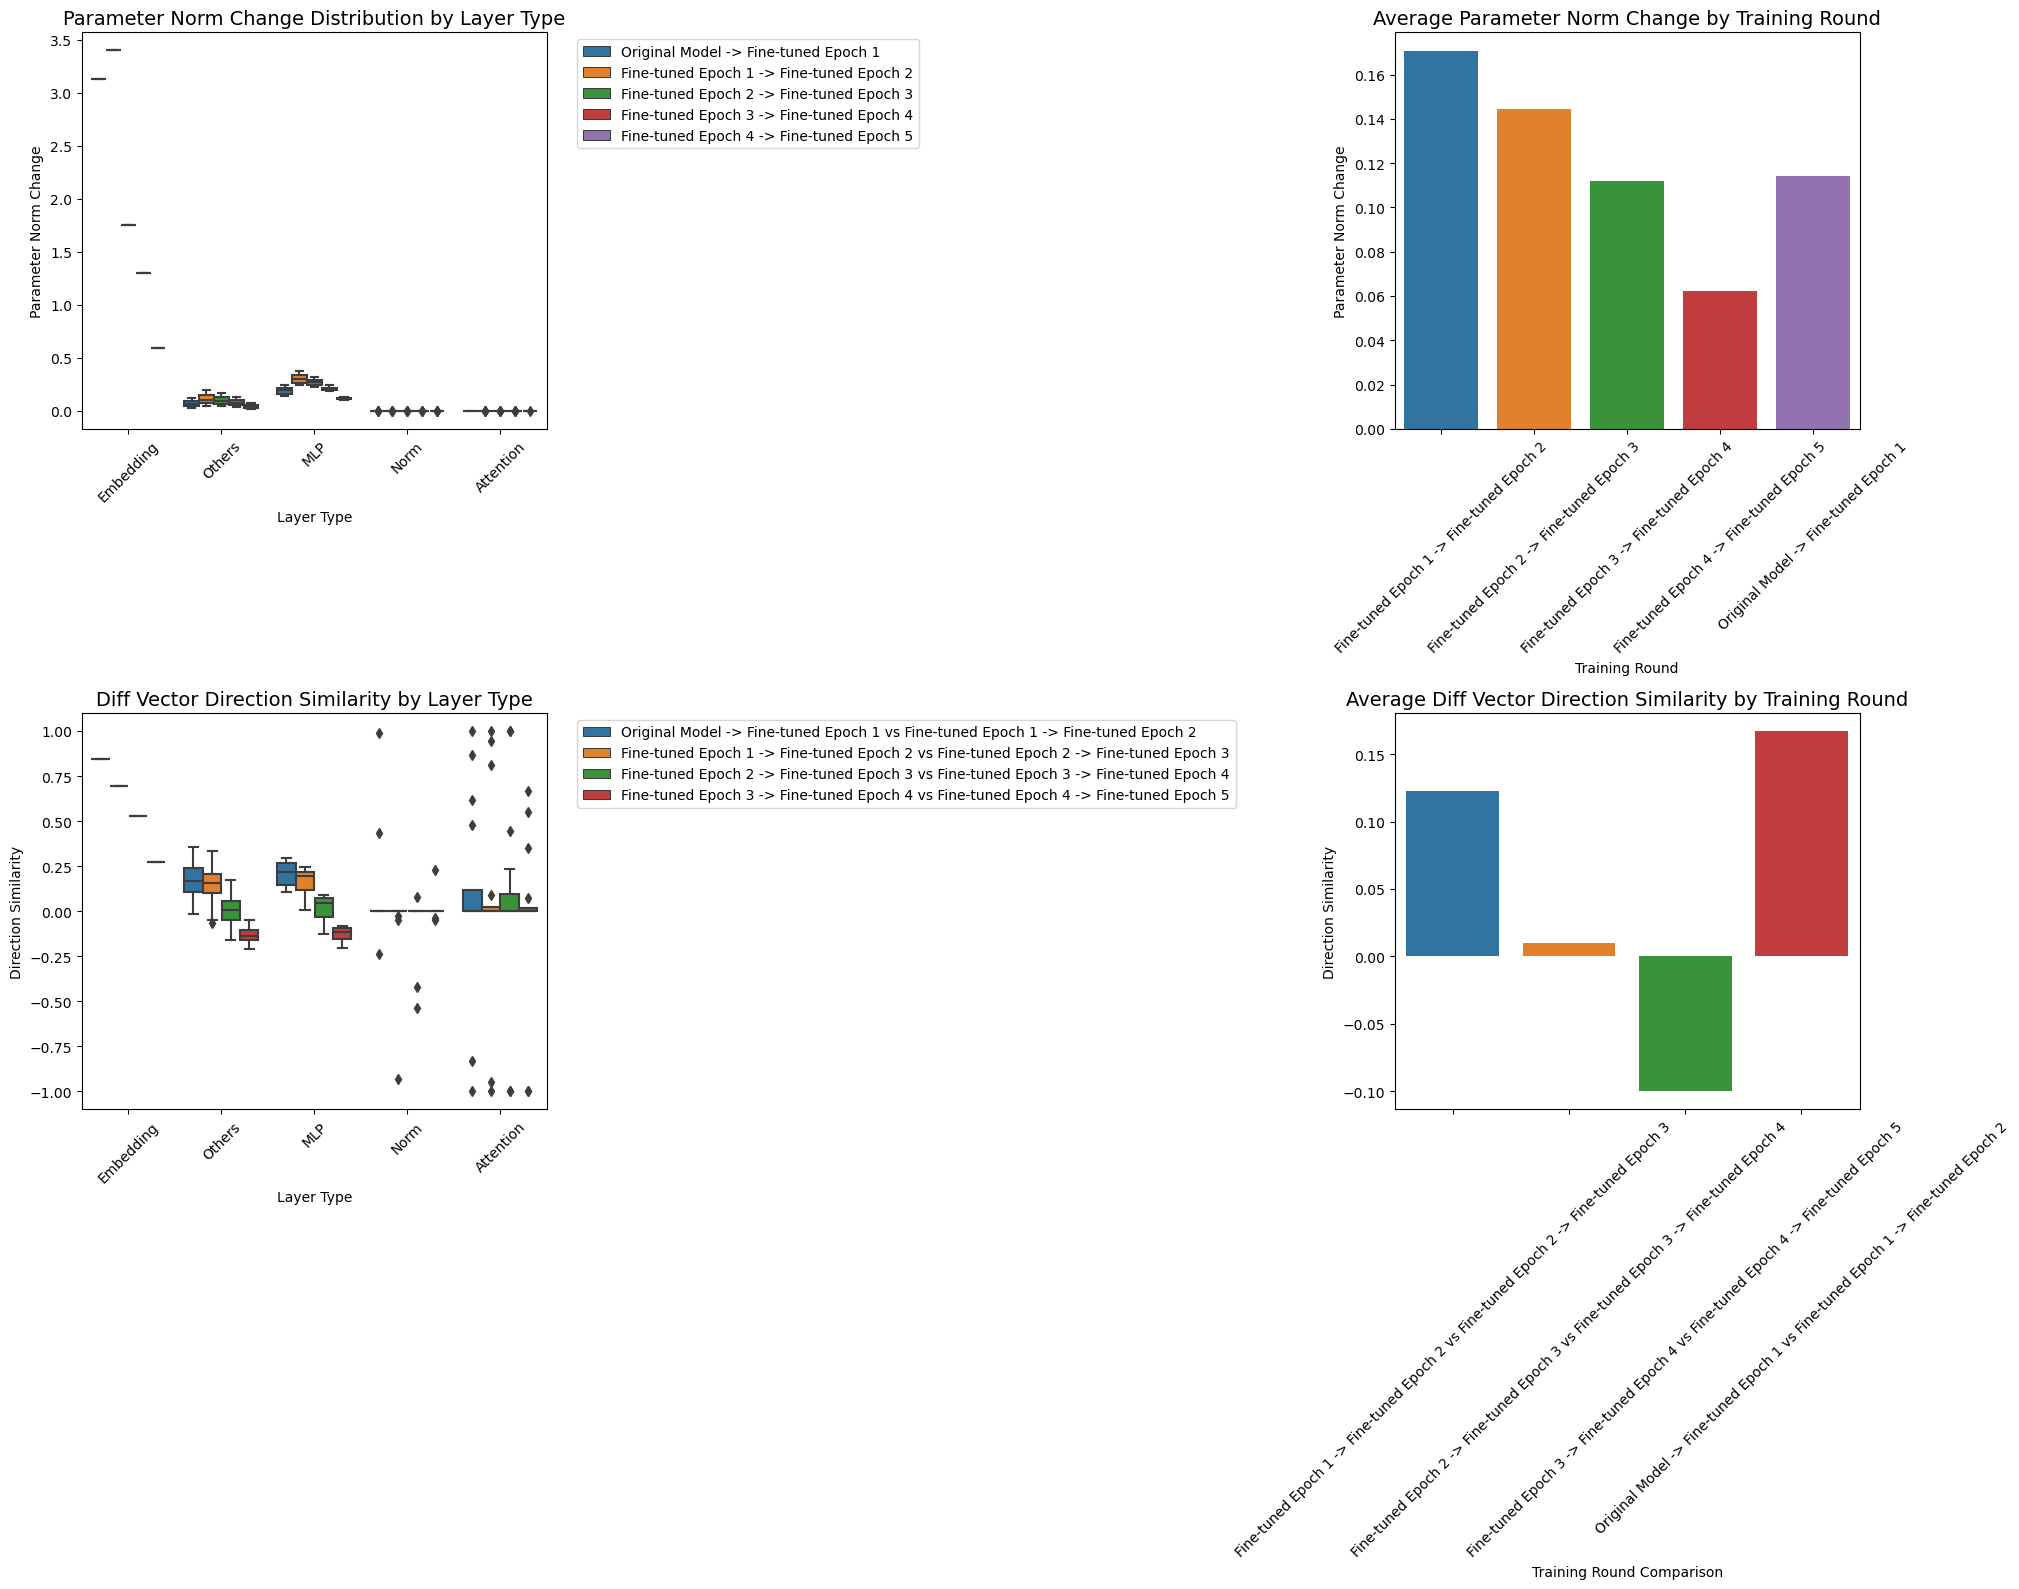


Average Parameter Norm Change by Training Round:
                             Training Round  Parameter Norm Change
0  Fine-tuned Epoch 1 -> Fine-tuned Epoch 2               0.170564
1  Fine-tuned Epoch 2 -> Fine-tuned Epoch 3               0.144473
2  Fine-tuned Epoch 3 -> Fine-tuned Epoch 4               0.111955
3  Fine-tuned Epoch 4 -> Fine-tuned Epoch 5               0.062398
4      Original Model -> Fine-tuned Epoch 1               0.114071

Average Diff Vector Direction Similarity by Training Round:
                           Training Round Comparison  Direction Similarity
0  Fine-tuned Epoch 1 -> Fine-tuned Epoch 2 vs Fi...              0.122809
1  Fine-tuned Epoch 2 -> Fine-tuned Epoch 3 vs Fi...              0.010257
2  Fine-tuned Epoch 3 -> Fine-tuned Epoch 4 vs Fi...             -0.100206
3  Original Model -> Fine-tuned Epoch 1 vs Fine-t...              0.167169


In [9]:
# 导入可视化库
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from collections import defaultdict

# 移除中文字体设置
# plt.rcParams['font.sans-serif'] = ['SimHei']
# plt.rcParams['axes.unicode_minus'] = False

# 计算两个参数差异向量之间的方向相似度
def compute_diff_vector_similarity(all_diffs):
    """计算相邻轮次间参数差异向量之间的方向相似度"""
    all_diff_cosine_sims = []
    
    # 对于每对相邻的差异向量，计算它们之间的相似度
    for i in range(len(all_diffs)-1):
        # 当前轮次的差异向量
        curr_diff = all_diffs[i]
        # 下一轮次的差异向量
        next_diff = all_diffs[i+1]
        
        # 存储每个参数的余弦相似度
        cosine_sim = {}
        
        # 计算每个参数的余弦相似度
        for param_name in curr_diff.keys():
            if param_name in next_diff:
                vec_curr = curr_diff[param_name].view(-1)
                vec_next = next_diff[param_name].view(-1)
                
                # 确保向量不为零
                if torch.norm(vec_curr) > 0 and torch.norm(vec_next) > 0:
                    cos_sim = torch.nn.functional.cosine_similarity(
                        vec_curr, vec_next, dim=0
                    ).item()
                    cosine_sim[param_name] = cos_sim
                else:
                    cosine_sim[param_name] = 0.0
        
        all_diff_cosine_sims.append(cosine_sim)
    
    return all_diff_cosine_sims

# 分析参数变化趋势
def analyze_parameter_changes():
    # 计算相邻差异向量之间的方向相似度
    diff_cosine_sims = compute_diff_vector_similarity(all_diffs)
    
    # 1. 按层类型分组计算平均L2范数变化
    layer_types = defaultdict(list)
    
    # 对每一轮的差异进行分析
    for round_idx, l2_norms in enumerate(all_l2_norms):
        round_name = f"{model_names[round_idx]} -> {model_names[round_idx+1]}"
        
        for param_name, norm_value in l2_norms.items():
            # 根据参数名称识别层类型
            if 'embed' in param_name:
                layer_type = 'Embedding'
            elif 'attention' in param_name:
                layer_type = 'Attention'
            elif 'mlp' in param_name:
                layer_type = 'MLP'
            elif 'norm' in param_name:
                layer_type = 'Norm'
            elif 'head' in param_name or 'lm_head' in param_name:
                layer_type = 'Output'
            else:
                layer_type = 'Others'
            
            layer_types[layer_type].append((round_name, norm_value))
    
    # 创建数据框以便可视化
    layer_data = []
    for layer_type, values in layer_types.items():
        for round_name, norm_value in values:
            layer_data.append({
                'Layer Type': layer_type,
                'Training Round': round_name,
                'Parameter Norm Change': norm_value
            })
    
    layer_df = pd.DataFrame(layer_data)
    
    # 分析差异向量之间的方向相似度
    direction_data = []
    
    # 只有len(all_diffs)-1个diff_cosine_sims，需要创建相应的标签
    for i, cosine_sims in enumerate(diff_cosine_sims):
        # 创建表示连续轮次的标签
        round_name = f"{model_names[i]} -> {model_names[i+1]} vs {model_names[i+1]} -> {model_names[i+2]}"
        
        for param_name, sim_value in cosine_sims.items():
            # 根据参数名称识别层类型
            if 'embed' in param_name:
                layer_type = 'Embedding'
            elif 'attention' in param_name:
                layer_type = 'Attention'
            elif 'mlp' in param_name:
                layer_type = 'MLP'
            elif 'norm' in param_name:
                layer_type = 'Norm'
            elif 'head' in param_name or 'lm_head' in param_name:
                layer_type = 'Output'
            else:
                layer_type = 'Others'
            
            direction_data.append({
                'Layer Type': layer_type,
                'Training Round Comparison': round_name,
                'Direction Similarity': sim_value
            })
    
    direction_df = pd.DataFrame(direction_data)
    
    return layer_df, direction_df

# 可视化参数变化
def visualize_parameter_changes(layer_df, direction_df):
    plt.figure(figsize=(20, 16))
    
    # 1. 不同层类型的参数变化范数分布（箱线图）
    plt.subplot(2, 2, 1)
    sns.boxplot(x='Layer Type', y='Parameter Norm Change', hue='Training Round', data=layer_df)
    plt.title('Parameter Norm Change Distribution by Layer Type', fontsize=14)
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 2. 各训练轮次的参数变化总体趋势
    plt.subplot(2, 2, 2)
    round_summary = layer_df.groupby('Training Round')['Parameter Norm Change'].mean().reset_index()
    sns.barplot(x='Training Round', y='Parameter Norm Change', data=round_summary)
    plt.title('Average Parameter Norm Change by Training Round', fontsize=14)
    plt.xticks(rotation=45)
    
    # 3. 参数差异向量之间的方向相似度
    plt.subplot(2, 2, 3)
    if not direction_df.empty:
        sns.boxplot(x='Layer Type', y='Direction Similarity', hue='Training Round Comparison', data=direction_df)
        plt.title('Diff Vector Direction Similarity by Layer Type', fontsize=14)
        plt.xticks(rotation=45)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        plt.text(0.5, 0.5, 'No direction data available', horizontalalignment='center', verticalalignment='center')
    
    # 4. 各训练轮次的参数差异向量方向相似度总体趋势
    plt.subplot(2, 2, 4)
    if not direction_df.empty:
        direction_summary = direction_df.groupby('Training Round Comparison')['Direction Similarity'].mean().reset_index()
        sns.barplot(x='Training Round Comparison', y='Direction Similarity', data=direction_summary)
        plt.title('Average Diff Vector Direction Similarity by Training Round', fontsize=14)
        plt.xticks(rotation=45)
    else:
        plt.text(0.5, 0.5, 'No direction data available', horizontalalignment='center', verticalalignment='center')
    
    plt.tight_layout()
    plt.savefig('parameter_changes.png', dpi=300)
    plt.show()
    
    return round_summary, direction_summary if not direction_df.empty else None

# 执行分析和可视化
layer_df, direction_df = analyze_parameter_changes()
results = visualize_parameter_changes(layer_df, direction_df)
round_summary = results[0]
direction_summary = results[1] if len(results) > 1 else None

# 打印总结数据
print("\nAverage Parameter Norm Change by Training Round:")
print(round_summary)

if direction_summary is not None:
    print("\nAverage Diff Vector Direction Similarity by Training Round:")
    print(direction_summary)

Analyzing task vector similarity...
Analyzing task vector components...
Plotting task vector similarity heatmap...
Analyzing task vector components...
Plotting task vector similarity heatmap...


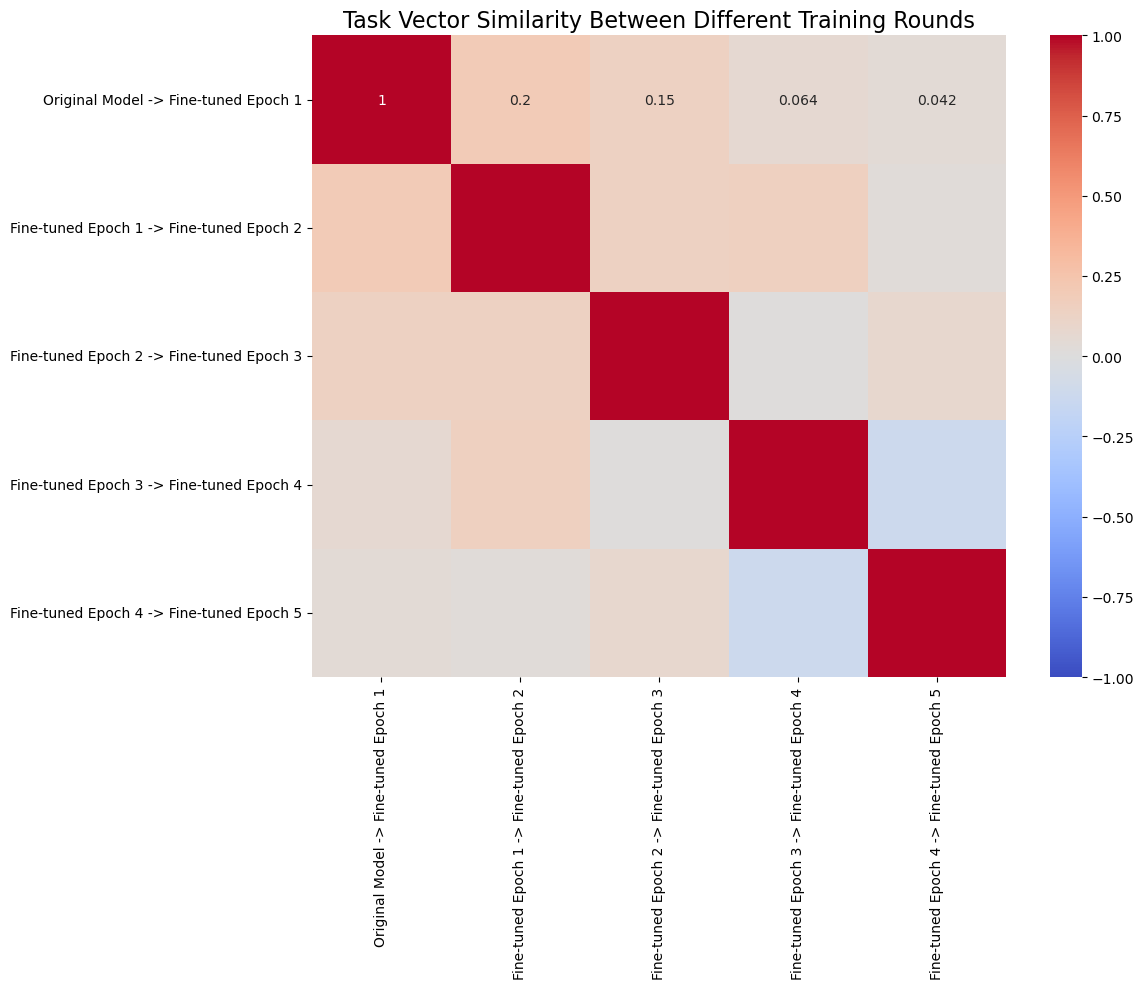

Plotting task vector component analysis...


/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/cnz/miniconda3/envs/unlearn/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: Future

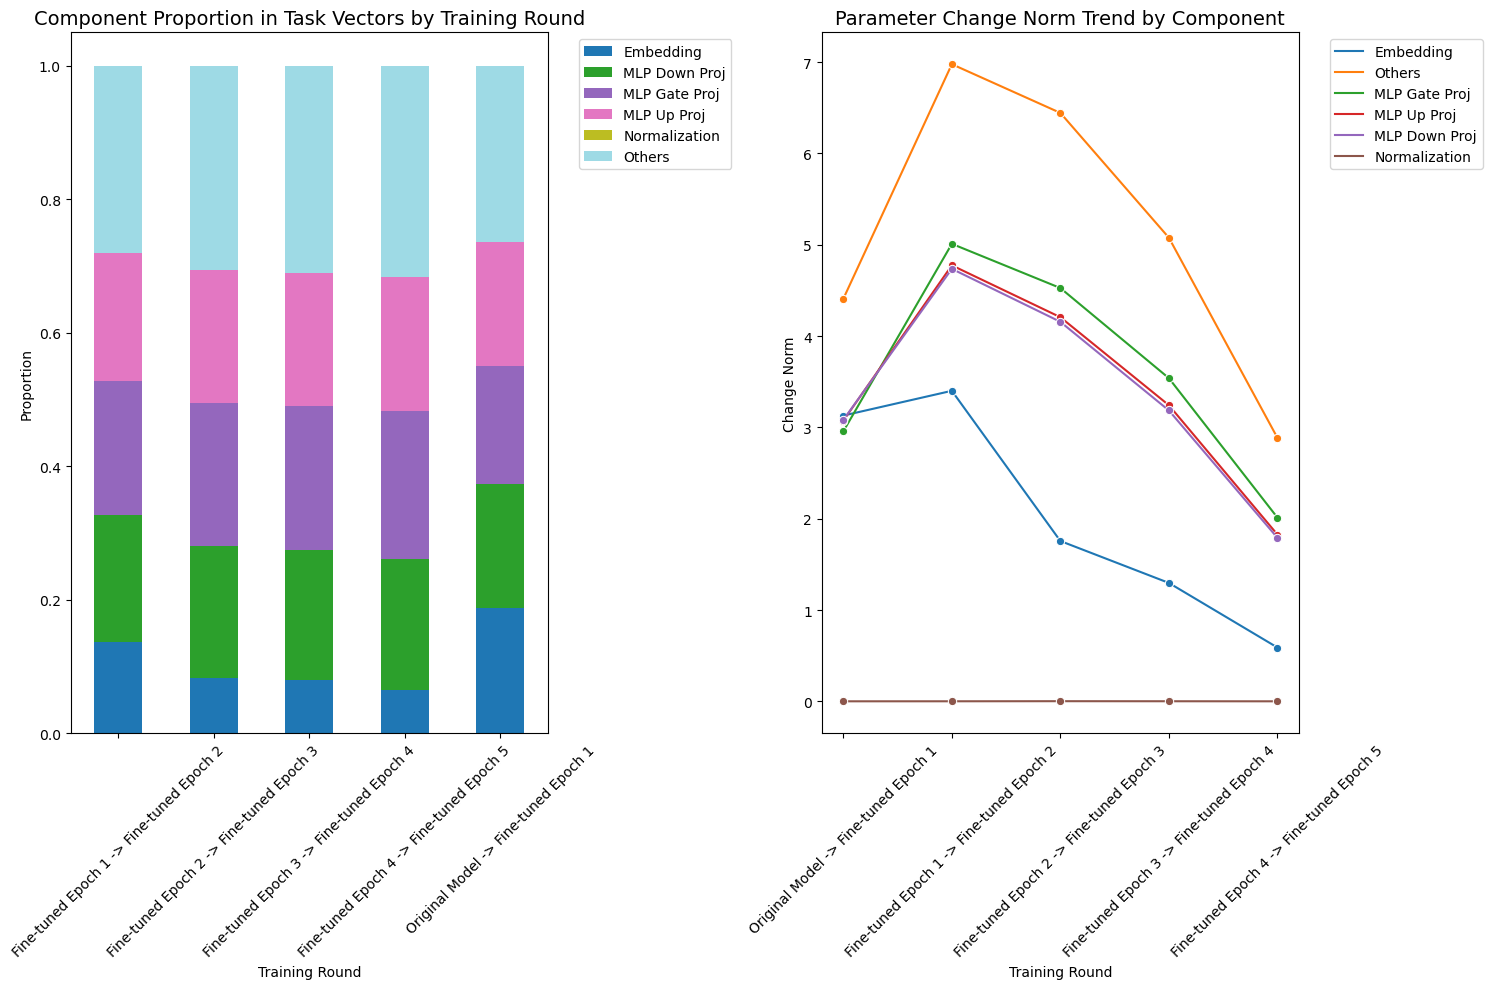


Task vector similarity between different training rounds:
Fine-tuned Epoch 1-Original Model vs Fine-tuned Epoch 2-Fine-tuned Epoch 1: 0.2001
Fine-tuned Epoch 1-Original Model vs Fine-tuned Epoch 3-Fine-tuned Epoch 2: 0.1469
Fine-tuned Epoch 1-Original Model vs Fine-tuned Epoch 4-Fine-tuned Epoch 3: 0.0640
Fine-tuned Epoch 1-Original Model vs Fine-tuned Epoch 5-Fine-tuned Epoch 4: 0.0421
Fine-tuned Epoch 2-Fine-tuned Epoch 1 vs Fine-tuned Epoch 3-Fine-tuned Epoch 2: 0.1470
Fine-tuned Epoch 2-Fine-tuned Epoch 1 vs Fine-tuned Epoch 4-Fine-tuned Epoch 3: 0.1559
Fine-tuned Epoch 2-Fine-tuned Epoch 1 vs Fine-tuned Epoch 5-Fine-tuned Epoch 4: 0.0301
Fine-tuned Epoch 3-Fine-tuned Epoch 2 vs Fine-tuned Epoch 4-Fine-tuned Epoch 3: 0.0122
Fine-tuned Epoch 3-Fine-tuned Epoch 2 vs Fine-tuned Epoch 5-Fine-tuned Epoch 4: 0.0818
Fine-tuned Epoch 4-Fine-tuned Epoch 3 vs Fine-tuned Epoch 5-Fine-tuned Epoch 4: -0.1199


In [10]:
# 更深入的任务向量分析

# 分析连续训练轮次之间的任务向量相似度
def analyze_task_vector_similarity():
    """分析不同训练轮次之间的任务向量相似度"""
    task_vector_similarities = {}
    
    # 对每一对任务向量计算余弦相似度
    for i in range(len(all_diffs)):
        for j in range(i+1, len(all_diffs)):
            similarity_scores = {}
            
            # 获取两个任务向量
            diff_i = all_diffs[i]
            diff_j = all_diffs[j]
            
            # 计算每个参数的余弦相似度
            for param_name in diff_i.keys():
                if param_name in diff_j:
                    vec_i = diff_i[param_name].view(-1)
                    vec_j = diff_j[param_name].view(-1)
                    
                    # 确保向量不为零
                    if torch.norm(vec_i) > 0 and torch.norm(vec_j) > 0:
                        cos_sim = torch.nn.functional.cosine_similarity(
                            vec_i, vec_j, dim=0
                        ).item()
                        similarity_scores[param_name] = cos_sim
            
            # 计算平均相似度
            avg_similarity = np.mean(list(similarity_scores.values()))
            key = f"{model_names[i+1]}-{model_names[i]} vs {model_names[j+1]}-{model_names[j]}"
            task_vector_similarities[key] = avg_similarity
    
    return task_vector_similarities

# 分析任务向量的主要成分
def analyze_task_vector_components():
    """分析每个任务向量的主要组成部分"""
    component_analysis = []
    
    for i, diff_params in enumerate(all_diffs):
        # 按参数类型分组
        param_types = defaultdict(float)
        
        for param_name, param_diff in diff_params.items():
            # 计算当前参数差异的范数
            norm = torch.norm(param_diff).item()
            
            # 按参数名称分类
            if 'embed' in param_name:
                param_types['Embedding'] += norm
            elif 'attention.q_proj' in param_name:
                param_types['Query Projection'] += norm
            elif 'attention.k_proj' in param_name:
                param_types['Key Projection'] += norm
            elif 'attention.v_proj' in param_name:
                param_types['Value Projection'] += norm
            elif 'attention.o_proj' in param_name:
                param_types['Output Projection'] += norm
            elif 'mlp.gate_proj' in param_name:
                param_types['MLP Gate Proj'] += norm
            elif 'mlp.up_proj' in param_name:
                param_types['MLP Up Proj'] += norm
            elif 'mlp.down_proj' in param_name:
                param_types['MLP Down Proj'] += norm
            elif 'norm' in param_name:
                param_types['Normalization'] += norm
            elif 'head' in param_name or 'lm_head' in param_name:
                param_types['Output Layer'] += norm
            else:
                param_types['Others'] += norm
        
        # 计算总范数
        total_norm = sum(param_types.values())
        
        # 计算每个组件的比例
        for component, norm in param_types.items():
            component_analysis.append({
                'Training Round': f"{model_names[i]} -> {model_names[i+1]}",
                'Parameter Component': component,
                'Change Norm': norm,
                'Proportion': norm / total_norm if total_norm > 0 else 0
            })
    
    return pd.DataFrame(component_analysis)

# 绘制任务向量相似度热图
def plot_task_vector_similarity(similarities):
    plt.figure(figsize=(12, 10))
    
    # 创建热图数据
    labels = list(similarities.keys())
    values = list(similarities.values())
    
    # 创建方形矩阵
    n = len(all_diffs)
    sim_matrix = np.zeros((n, n))
    
    # 填充矩阵
    idx = 0
    for i in range(n):
        sim_matrix[i, i] = 1.0  # 自己与自己的相似度为1
        for j in range(i+1, n):
            sim_matrix[i, j] = values[idx]
            sim_matrix[j, i] = values[idx]  # 矩阵对称
            idx += 1
    
    # 创建轮次标签
    round_labels = [f"{model_names[i]} -> {model_names[i+1]}" for i in range(n)]
    
    # 绘制热图
    sns.heatmap(sim_matrix, annot=True, cmap='coolwarm', 
                xticklabels=round_labels, yticklabels=round_labels,
                vmin=-1, vmax=1)
    
    plt.title('Task Vector Similarity Between Different Training Rounds', fontsize=16)
    plt.tight_layout()
    plt.savefig('task_vector_similarity.png', dpi=300)
    plt.show()

# 绘制任务向量组件分析图
def plot_component_analysis(component_df):
    plt.figure(figsize=(15, 10))
    
    # 1. 组件比例堆叠条形图
    plt.subplot(1, 2, 1)
    pivot_df = component_df.pivot_table(
        index='Training Round', columns='Parameter Component', values='Proportion', aggfunc='sum'
    ).fillna(0)
    
    pivot_df.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='tab20')
    plt.title('Component Proportion in Task Vectors by Training Round', fontsize=14)
    plt.xlabel('Training Round')
    plt.ylabel('Proportion')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    
    # 2. 组件范数变化趋势
    plt.subplot(1, 2, 2)
    sns.lineplot(x='Training Round', y='Change Norm', hue='Parameter Component', 
                data=component_df, marker='o')
    plt.title('Parameter Change Norm Trend by Component', fontsize=14)
    plt.xticks(rotation=45)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig('component_analysis.png', dpi=300)
    plt.show()

# 执行深入分析
print("Analyzing task vector similarity...")
task_similarities = analyze_task_vector_similarity()
print("Analyzing task vector components...")
component_df = analyze_task_vector_components()

# 可视化结果
print("Plotting task vector similarity heatmap...")
plot_task_vector_similarity(task_similarities)
print("Plotting task vector component analysis...")
plot_component_analysis(component_df)

# 打印相似度数据
print("\nTask vector similarity between different training rounds:")
for key, value in task_similarities.items():
    print(f"{key}: {value:.4f}")

Computing normalized parameter differences...
Visualizing normalized parameter changes...
Visualizing normalized parameter changes...


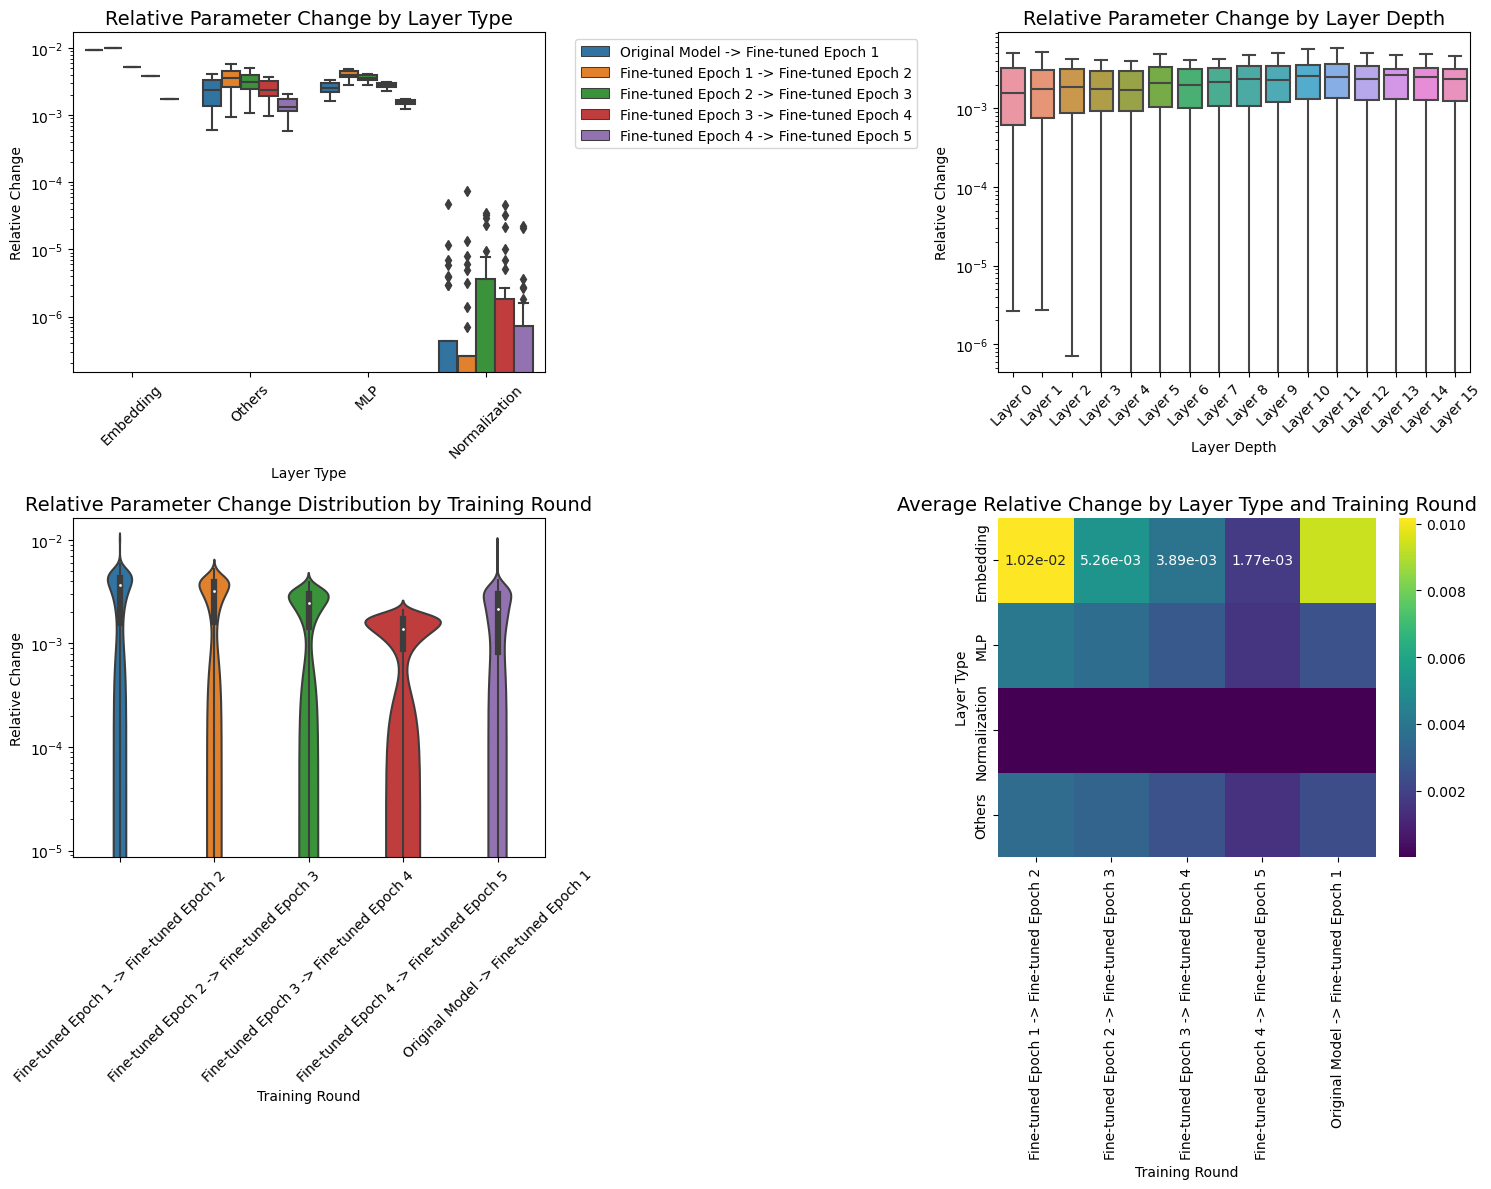


===== Model Parameter Change Analysis Summary =====

1. Overall Parameter Change Trends:
  Fine-tuned Epoch 1 -> Fine-tuned Epoch 2: Average Norm Change = 0.170564
  Fine-tuned Epoch 2 -> Fine-tuned Epoch 3: Average Norm Change = 0.144473
  Fine-tuned Epoch 3 -> Fine-tuned Epoch 4: Average Norm Change = 0.111955
  Fine-tuned Epoch 4 -> Fine-tuned Epoch 5: Average Norm Change = 0.062398
  Original Model -> Fine-tuned Epoch 1: Average Norm Change = 0.114071

2. Difference Vector Direction Similarity Summary:
  Fine-tuned Epoch 1 -> Fine-tuned Epoch 2 vs Fine-tuned Epoch 2 -> Fine-tuned Epoch 3: Average Direction Similarity = 0.122809
  Fine-tuned Epoch 2 -> Fine-tuned Epoch 3 vs Fine-tuned Epoch 3 -> Fine-tuned Epoch 4: Average Direction Similarity = 0.010257
  Fine-tuned Epoch 3 -> Fine-tuned Epoch 4 vs Fine-tuned Epoch 4 -> Fine-tuned Epoch 5: Average Direction Similarity = -0.100206
  Original Model -> Fine-tuned Epoch 1 vs Fine-tuned Epoch 1 -> Fine-tuned Epoch 2: Average Direction 

In [11]:
# 进一步分析任务向量的可解释性和模型行为变化

# 计算参数差异的归一化幅度
def compute_normalized_diffs():
    """计算每一轮参数差异相对于原参数大小的归一化幅度"""
    normalized_diffs = []
    
    for round_idx, diff_params in enumerate(all_diffs):
        # 获取当前轮次的模型
        current_model = models[round_idx]
        
        # 计算每个参数的归一化差异
        param_rel_changes = {}
        
        for name, diff in diff_params.items():
            # 获取原始参数
            orig_param = dict(current_model.named_parameters())[name].detach().float()
            
            # 计算相对变化 (|diff| / |orig_param|)
            if torch.norm(orig_param) > 0:
                rel_change = torch.norm(diff) / torch.norm(orig_param)
                param_rel_changes[name] = rel_change.item()
        
        # 添加到结果列表
        normalized_diffs.append(param_rel_changes)
    
    return normalized_diffs

# 可视化归一化参数变化
def visualize_normalized_changes(normalized_diffs):
    plt.figure(figsize=(15, 12))
    
    # 准备数据
    data = []
    for round_idx, param_changes in enumerate(normalized_diffs):
        round_name = f"{model_names[round_idx]} -> {model_names[round_idx+1]}"
        
        for param_name, rel_change in param_changes.items():
            # 分类参数
            if 'embed' in param_name:
                layer_type = 'Embedding'
            elif 'attention.q_proj' in param_name:
                layer_type = 'Query Projection'
            elif 'attention.k_proj' in param_name:
                layer_type = 'Key Projection'
            elif 'attention.v_proj' in param_name:
                layer_type = 'Value Projection'
            elif 'attention.o_proj' in param_name:
                layer_type = 'Output Projection'
            elif 'mlp' in param_name:
                layer_type = 'MLP'
            elif 'norm' in param_name:
                layer_type = 'Normalization'
            elif 'head' in param_name or 'lm_head' in param_name:
                layer_type = 'Output Layer'
            else:
                layer_type = 'Others'
            
            # 提取层深度信息（如果有）
            if 'layers.' in param_name:
                try:
                    # 尝试提取层索引
                    layer_idx = int(param_name.split('layers.')[1].split('.')[0])
                    depth_category = f"Layer {layer_idx}"
                except:
                    depth_category = "Unknown Layer"
            else:
                depth_category = "Global Layer"
            
            data.append({
                'Training Round': round_name,
                'Layer Type': layer_type,
                'Layer Depth': depth_category,
                'Relative Change': rel_change
            })
    
    df = pd.DataFrame(data)
    
    # 1. 各层类型的相对变化幅度
    plt.subplot(2, 2, 1)
    sns.boxplot(x='Layer Type', y='Relative Change', hue='Training Round', data=df)
    plt.title('Relative Parameter Change by Layer Type', fontsize=14)
    plt.xticks(rotation=45)
    plt.yscale('log')  # 使用对数尺度更好地显示数据分布
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 2. 各层深度的相对变化幅度
    plt.subplot(2, 2, 2)
    # 过滤掉非特定层的数据
    depth_df = df[df['Layer Depth'] != "Global Layer"].copy()
    # 确保层深度是排序的
    if not depth_df.empty:
        depth_order = sorted(depth_df['Layer Depth'].unique(), 
                           key=lambda x: int(x.split(' ')[1]) if x != "Unknown Layer" else 999)
        sns.boxplot(x='Layer Depth', y='Relative Change', data=depth_df, order=depth_order)
        plt.title('Relative Parameter Change by Layer Depth', fontsize=14)
        plt.xticks(rotation=45)
        plt.yscale('log')
    
    # 3. 各训练轮次的相对变化幅度分布
    plt.subplot(2, 2, 3)
    round_order = sorted(df['Training Round'].unique())
    sns.violinplot(x='Training Round', y='Relative Change', data=df, order=round_order)
    plt.title('Relative Parameter Change Distribution by Training Round', fontsize=14)
    plt.xticks(rotation=45)
    plt.yscale('log')
    
    # 4. 热图：层类型和训练轮次的关系
    plt.subplot(2, 2, 4)
    pivot = df.pivot_table(index='Layer Type', columns='Training Round', 
                          values='Relative Change', aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.2e', cmap='viridis')
    plt.title('Average Relative Change by Layer Type and Training Round', fontsize=14)
    plt.tight_layout()
    
    plt.savefig('normalized_parameter_changes.png', dpi=300)
    plt.show()
    
    return df

# 执行归一化差异分析
print("Computing normalized parameter differences...")
normalized_diffs = compute_normalized_diffs()
print("Visualizing normalized parameter changes...")
norm_changes_df = visualize_normalized_changes(normalized_diffs)

# 总结分析结果
def summarize_analysis():
    """总结所有分析结果"""
    print("\n===== Model Parameter Change Analysis Summary =====")
    
    # 1. 整体变化趋势
    print("\n1. Overall Parameter Change Trends:")
    for i, round_name in enumerate(round_summary['Training Round']):
        print(f"  {round_name}: Average Norm Change = {round_summary['Parameter Norm Change'].iloc[i]:.6f}")
    
    # 2. 差异向量方向相似度
    if direction_summary is not None:
        print("\n2. Difference Vector Direction Similarity Summary:")
        for i, round_comp in enumerate(direction_summary['Training Round Comparison']):
            print(f"  {round_comp}: Average Direction Similarity = {direction_summary['Direction Similarity'].iloc[i]:.6f}")
    
    # 3. 任务向量相似度
    print("\n3. Task Vector Similarity Summary:")
    # 找出最相似和最不相似的任务向量对
    if task_similarities:
        most_similar = max(task_similarities.items(), key=lambda x: x[1])
        least_similar = min(task_similarities.items(), key=lambda x: x[1])
        print(f"  Most similar task vector pair: {most_similar[0]} (similarity: {most_similar[1]:.4f})")
        print(f"  Least similar task vector pair: {least_similar[0]} (similarity: {least_similar[1]:.4f})")
    
    # 4. 参数组件变化
    print("\n4. Parameter Component Change Summary:")
    # 按轮次分组，找出变化最大的组件
    for round_name in component_df['Training Round'].unique():
        round_data = component_df[component_df['Training Round'] == round_name]
        max_component = round_data.loc[round_data['Change Norm'].idxmax()]
        print(f"  {round_name}: Component with largest change is {max_component['Parameter Component']} " +
              f"(norm: {max_component['Change Norm']:.6f}, proportion: {max_component['Proportion']*100:.2f}%)")
    
    # 5. 归一化参数变化
    print("\n5. Normalized Parameter Change Summary:")
    # 按层类型计算平均归一化变化
    layer_type_summary = norm_changes_df.groupby('Layer Type')['Relative Change'].mean().sort_values(ascending=False)
    print("  Average relative change by layer type (descending):")
    for layer_type, rel_change in layer_type_summary.items():
        print(f"    {layer_type}: {rel_change:.6f}")
    
    print("\n===== Analysis Complete =====")

# 执行总结
summarize_analysis()

# 一致性实验：不同seed微调模型的参数变化分析

分析同一数据集用不同seed微调5次后，模型MLP层proj权重的变化程度。

## 问题修复说明

### 问题1：Delta Direction为何出现负值？

**原因**：
- 余弦相似度 $\cos(\theta_i, \theta_j) = \frac{\theta_i \cdot \theta_j}{||\theta_i|| \cdot ||\theta_j||}$ 的理论范围是 $[-1, 1]$
- 由于浮点数精度问题，计算结果可能略微超出这个范围
- 当 $\cos(\theta_i, \theta_j) > 1$ 时，$1 - \cos(\theta_i, \theta_j) < 0$

**解决方案**：
1. 使用 `torch.clamp(cosine_sim, -1.0, 1.0)` 确保余弦值在有效范围内
2. 使用 `max(0.0, delta_direction)` 确保最终结果非负
3. 这样保证 Delta Direction 始终在 $[0, 2]$ 范围内，实际值通常在 $[0, 1]$ 之间

### 问题2：可视化设计

参考 SVHN 风格的散点图设计：
- **横轴**：ΔDirection (范围 0-1)
- **纵轴**：ΔMagnitude (范围 0-1)  
- **颜色**：用渐变色表示层深度
- **形状**：不同的投影类型使用不同的marker
- **样式**：简洁的网格背景，白色边框的散点

这种可视化方式能清晰展示不同层的参数变化模式。

In [2]:
# 内存监控工具
import psutil
import os
import torch

def print_memory_usage():
    """打印当前进程的内存使用情况"""
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    mem_mb = mem_info.rss / 1024 / 1024
    print(f"当前内存使用: {mem_mb:.2f} MB")
    
    # 如果有GPU，也显示GPU内存
    if torch.cuda.is_available():
        for i in range(torch.cuda.device_count()):
            mem_allocated = torch.cuda.memory_allocated(i) / 1024 / 1024
            mem_reserved = torch.cuda.memory_reserved(i) / 1024 / 1024
            print(f"GPU {i} - 已分配: {mem_allocated:.2f} MB, 已保留: {mem_reserved:.2f} MB")

print("初始内存状态:")
print_memory_usage()

初始内存状态:
当前内存使用: 389.46 MB


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from transformers import AutoModelForCausalLM
from itertools import combinations
from tqdm import tqdm
import gc

# 设置绘图风格
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 模型路径
base_path = Path("/cnz/data/project/my-open-unlearning/saves/finetune/consistency_exp/Llama-3.2-1B-Instruct")
model_paths = [
    base_path / "run0_seed42",
    base_path / "run1_seed142", 
    base_path / "run2_seed242",
    base_path / "run3_seed342",
    base_path / "run4_seed442"
]

print(f"找到 {len(model_paths)} 个模型")
print("使用内存优化策略：逐个加载和提取权重")
print("="*60)

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


找到 5 个模型
使用内存优化策略：逐个加载和提取权重


In [4]:
# 提取MLP层的proj权重（内存优化版）
def extract_mlp_proj_weights(model):
    """
    提取模型中所有MLP层的proj权重
    返回: dict，键为层名，值为权重张量
    """
    mlp_weights = {}
    
    for name, param in model.named_parameters():
        # 查找MLP层中的proj权重（包括gate_proj, up_proj, down_proj）
        if 'mlp' in name and ('gate_proj' in name or 'up_proj' in name or 'down_proj' in name):
            if 'weight' in name:
                # 复制到CPU并立即转换为float32以节省内存
                mlp_weights[name] = param.data.clone().cpu().float()
    
    return mlp_weights

def load_and_extract_weights(model_path):
    """
    加载模型并提取权重，然后立即释放模型
    """
    print(f"  加载: {model_path.name}")
    model = AutoModelForCausalLM.from_pretrained(
        str(model_path),
        torch_dtype=torch.float32,
        device_map='cpu',
        low_cpu_mem_usage=True
    )
    
    print(f"  提取权重...")
    weights = extract_mlp_proj_weights(model)
    
    # 立即删除模型并清理内存
    del model
    gc.collect()
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    print(f"  完成，提取了 {len(weights)} 个层")
    return weights

# 逐个加载模型并提取权重
print("开始提取所有模型的MLP proj权重...")
print("="*60)
all_model_weights = []

for i, path in enumerate(model_paths):
    print(f"\n[{i+1}/{len(model_paths)}]")
    weights = load_and_extract_weights(path)
    all_model_weights.append(weights)
    print(f"  内存已清理")

# 检查所有模型的层名是否一致
layer_names = list(all_model_weights[0].keys())
print(f"\n{'='*60}")
print(f"提取完成！")
print(f"总MLP proj层数: {len(layer_names)}")
print(f"示例层: {layer_names[:3]}")
print(f"{'='*60}")

开始提取所有模型的MLP proj权重...

[1/5]
  加载: run0_seed42
  提取权重...
  完成，提取了 48 个层
  内存已清理

[2/5]
  加载: run1_seed142
  提取权重...
  完成，提取了 48 个层
  内存已清理

[3/5]
  加载: run2_seed242
  提取权重...
  完成，提取了 48 个层
  内存已清理

[4/5]
  加载: run3_seed342
  提取权重...
  完成，提取了 48 个层
  内存已清理

[5/5]
  加载: run4_seed442
  提取权重...
  完成，提取了 48 个层
  内存已清理

提取完成！
总MLP proj层数: 48
示例层: ['model.layers.0.mlp.gate_proj.weight', 'model.layers.0.mlp.up_proj.weight', 'model.layers.0.mlp.down_proj.weight']


In [7]:
# 计算两个权重张量之间的delta magnitude和delta direction
def compute_delta_metrics(weight_i, weight_j):
    """
    计算两个权重张量之间的变化指标
    
    Args:
        weight_i: 权重张量i
        weight_j: 权重张量j
    
    Returns:
        delta_magnitude: (||theta_i|| - ||theta_j||) / ||theta_i||
        delta_direction: 1 - cos(theta_i, theta_j)
    """
    # 展平为向量
    vec_i = weight_i.flatten().float()
    vec_j = weight_j.flatten().float()
    
    # 计算范数
    norm_i = torch.norm(vec_i)
    norm_j = torch.norm(vec_j)
    
    # Delta Magnitude: |norm_i - norm_j| / norm_i
    delta_magnitude = abs((norm_i - norm_j) / norm_i).item()
    
    # Delta Direction: 1 - cos(theta_i, theta_j)
    # 余弦相似度范围[-1, 1]，确保结果在[0, 2]，然后限制在[0, 1]
    cosine_sim = torch.dot(vec_i, vec_j) / (norm_i * norm_j)
    # 限制cosine_sim在[-1, 1]范围内（避免数值误差）
    cosine_sim = torch.clamp(cosine_sim, -1.0, 1.0)
    delta_direction = (1 - cosine_sim).item()
    # 确保在[0, 1]范围内：如果两个向量方向相同，结果接近0；如果相反，结果接近2，需要归一化
    # 实际上1-cos的范围是[0, 2]，为了与参考图一致，可以除以2归一化到[0,1]
    # 但根据公式定义，应该保持原值，只是确保非负
    delta_direction = max(0.0, delta_direction)
    
    # 立即删除临时向量
    del vec_i, vec_j
    
    return delta_magnitude, delta_direction

# 计算所有模型对之间的delta metrics（内存优化版）
print("计算所有模型对之间的delta metrics...")
print("="*60)
delta_results = {layer_name: {'magnitude': [], 'direction': []} for layer_name in layer_names}

# 获取所有模型对的组合 (共10对)
model_pairs = list(combinations(range(len(model_paths)), 2))
print(f"模型对总数: {len(model_pairs)}")
print(f"每对需要比较 {len(layer_names)} 个层")

for pair_idx, (i, j) in enumerate(tqdm(model_pairs, desc="处理模型对")):
    for layer_name in layer_names:
        weight_i = all_model_weights[i][layer_name]
        weight_j = all_model_weights[j][layer_name]
        
        delta_mag, delta_dir = compute_delta_metrics(weight_i, weight_j)
        
        delta_results[layer_name]['magnitude'].append(delta_mag)
        delta_results[layer_name]['direction'].append(delta_dir)
    

    # 每处理完一对模型，清理一次内存print("="*60)

    if (pair_idx + 1) % 3 == 0:
        print("Delta metrics计算完成！")

        gc.collect()
        
        print("\n" + "="*60)


计算所有模型对之间的delta metrics...
模型对总数: 10
每对需要比较 48 个层


处理模型对:   0%|          | 0/10 [00:00<?, ?it/s]

处理模型对:  30%|███       | 3/10 [00:12<00:26,  3.85s/it]

Delta metrics计算完成！



处理模型对:  50%|█████     | 5/10 [00:18<00:16,  3.37s/it]

Delta metrics计算完成！


处理模型对:  60%|██████    | 6/10 [00:20<00:11,  2.94s/it]

处理模型对:  90%|█████████ | 9/10 [00:27<00:02,  2.34s/it]

Delta metrics计算完成！



处理模型对: 100%|██████████| 10/10 [00:28<00:00,  2.87s/it]


## Delta Metrics 数学定义

### Delta Magnitude
$$\Delta \text{Magnitude} = \frac{||\theta_i|| - ||\theta_j||}{||\theta_i||}$$

表示两个权重向量的**范数（模长）差异**的相对比例。

### Delta Direction  
$$\Delta \text{Direction} = 1 - \cos(\theta_i, \theta_j) = 1 - \frac{\theta_i \cdot \theta_j}{||\theta_i|| \cdot ||\theta_j||}$$

表示两个权重向量的**方向差异**：
- $\cos(\theta_i, \theta_j) \in [-1, 1]$
- 当两个向量方向完全相同时，$\cos = 1$，$\Delta\text{Direction} = 0$
- 当两个向量垂直时，$\cos = 0$，$\Delta\text{Direction} = 1$  
- 当两个向量方向相反时，$\cos = -1$，$\Delta\text{Direction} = 2$

**注意**：在实际中，由于权重初始化的随机性，大多数情况下$\Delta\text{Direction}$会在$[0, 1]$范围内，很少出现负值（需要通过clamp确保数值稳定性）。

In [8]:
# 验证Delta Direction计算的正确性
print("Delta Direction 计算验证：")
print("="*60)

# 测试案例
test_vec1 = torch.tensor([1.0, 0.0, 0.0])
test_vec2 = torch.tensor([1.0, 0.0, 0.0])  # 相同方向
test_vec3 = torch.tensor([-1.0, 0.0, 0.0])  # 相反方向
test_vec4 = torch.tensor([0.0, 1.0, 0.0])  # 垂直

def test_delta_direction(v1, v2, description):
    cos_sim = torch.dot(v1, v2) / (torch.norm(v1) * torch.norm(v2))
    cos_sim = torch.clamp(cos_sim, -1.0, 1.0)
    delta_dir = max(0.0, (1 - cos_sim).item())
    print(f"{description:30s} cos={cos_sim.item():7.4f}  Δdir={delta_dir:.4f}")

test_delta_direction(test_vec1, test_vec2, "相同方向 (0°)")
test_delta_direction(test_vec1, test_vec4, "垂直 (90°)")
test_delta_direction(test_vec1, test_vec3, "相反方向 (180°)")

print("\n结论：")
print("  - 相同方向：Δdir ≈ 0")
print("  - 垂直：Δdir ≈ 1")
print("  - 相反方向：Δdir ≈ 2 (但在实际权重中很少出现)")
print("  - 所有值均为非负 ✓")
print("="*60)

Delta Direction 计算验证：
相同方向 (0°)                      cos= 1.0000  Δdir=0.0000
垂直 (90°)                       cos= 0.0000  Δdir=1.0000
相反方向 (180°)                    cos=-1.0000  Δdir=2.0000

结论：
  - 相同方向：Δdir ≈ 0
  - 垂直：Δdir ≈ 1
  - 相反方向：Δdir ≈ 2 (但在实际权重中很少出现)
  - 所有值均为非负 ✓


In [9]:
# 统计分析
print("="*60)
print("Delta Metrics Statistics")
print("="*60)

all_magnitudes = []
all_directions = []

for layer_name in layer_names:
    all_magnitudes.extend(delta_results[layer_name]['magnitude'])
    all_directions.extend(delta_results[layer_name]['direction'])

print(f"\nDelta Magnitude:")
print(f"  Mean: {np.mean(all_magnitudes):.6f}")
print(f"  Std:  {np.std(all_magnitudes):.6f}")
print(f"  Min:  {np.min(all_magnitudes):.6f}")
print(f"  Max:  {np.max(all_magnitudes):.6f}")

print(f"\nDelta Direction:")
print(f"  Mean: {np.mean(all_directions):.6f}")
print(f"  Std:  {np.std(all_directions):.6f}")
print(f"  Min:  {np.min(all_directions):.6f}")
print(f"  Max:  {np.max(all_directions):.6f}")

# 按层统计
print(f"\n{'Layer':<60} {'Mag Mean':<12} {'Dir Mean':<12}")
print("-"*84)
for layer_name in layer_names[:5]:  # 显示前5层
    mag_mean = np.mean(delta_results[layer_name]['magnitude'])
    dir_mean = np.mean(delta_results[layer_name]['direction'])
    print(f"{layer_name:<60} {mag_mean:<12.6f} {dir_mean:<12.6f}")

print("\n内存状态:")
print_memory_usage()

Delta Metrics Statistics

Delta Magnitude:
  Mean: 0.000002
  Std:  0.000002
  Min:  0.000000
  Max:  0.000010

Delta Direction:
  Mean: 0.000000
  Std:  0.000000
  Min:  0.000000
  Max:  0.000000

Layer                                                        Mag Mean     Dir Mean    
------------------------------------------------------------------------------------
model.layers.0.mlp.gate_proj.weight                          0.000001     0.000000    
model.layers.0.mlp.up_proj.weight                            0.000003     0.000000    
model.layers.0.mlp.down_proj.weight                          0.000001     0.000000    
model.layers.1.mlp.gate_proj.weight                          0.000003     0.000000    
model.layers.1.mlp.up_proj.weight                            0.000002     0.000000    

内存状态:
当前内存使用: 18377.62 MB


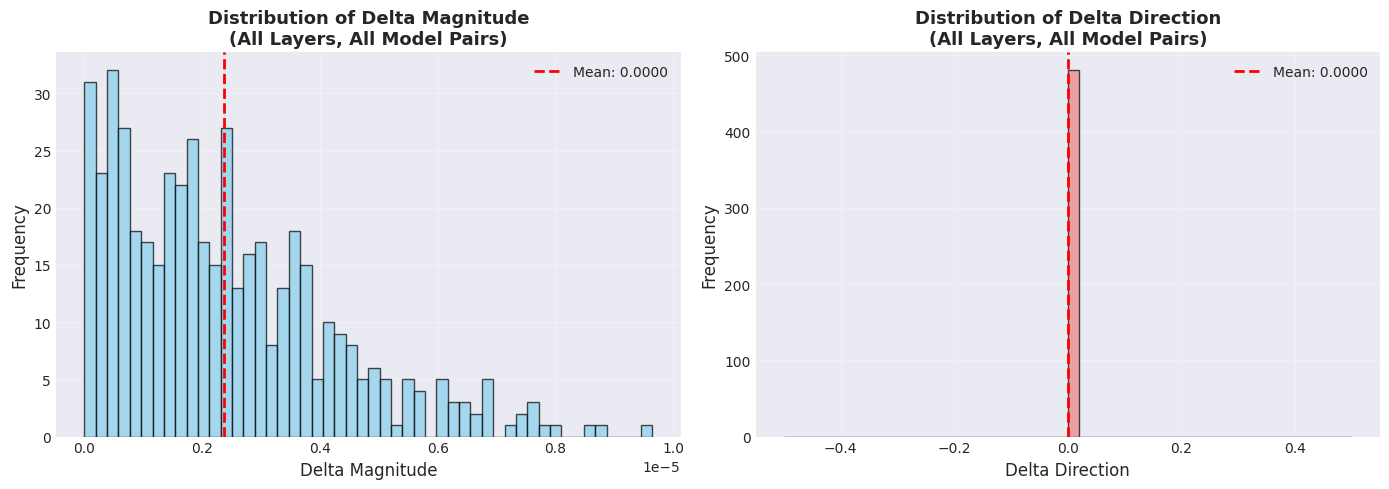

Overall distribution plot saved!


3

In [10]:
# 可视化1: 整体分布 - 所有层的delta metrics分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delta Magnitude分布
axes[0].hist(all_magnitudes, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(np.mean(all_magnitudes), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_magnitudes):.4f}')
axes[0].set_xlabel('Delta Magnitude', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Delta Magnitude\n(All Layers, All Model Pairs)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Delta Direction分布
axes[1].hist(all_directions, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].axvline(np.mean(all_directions), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_directions):.4f}')
axes[1].set_xlabel('Delta Direction', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Delta Direction\n(All Layers, All Model Pairs)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/cnz/data/project/my-open-unlearning/notebooks/consistency_overall_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)  # 关闭图形释放内存

print("Overall distribution plot saved!")
gc.collect()  # 清理内存

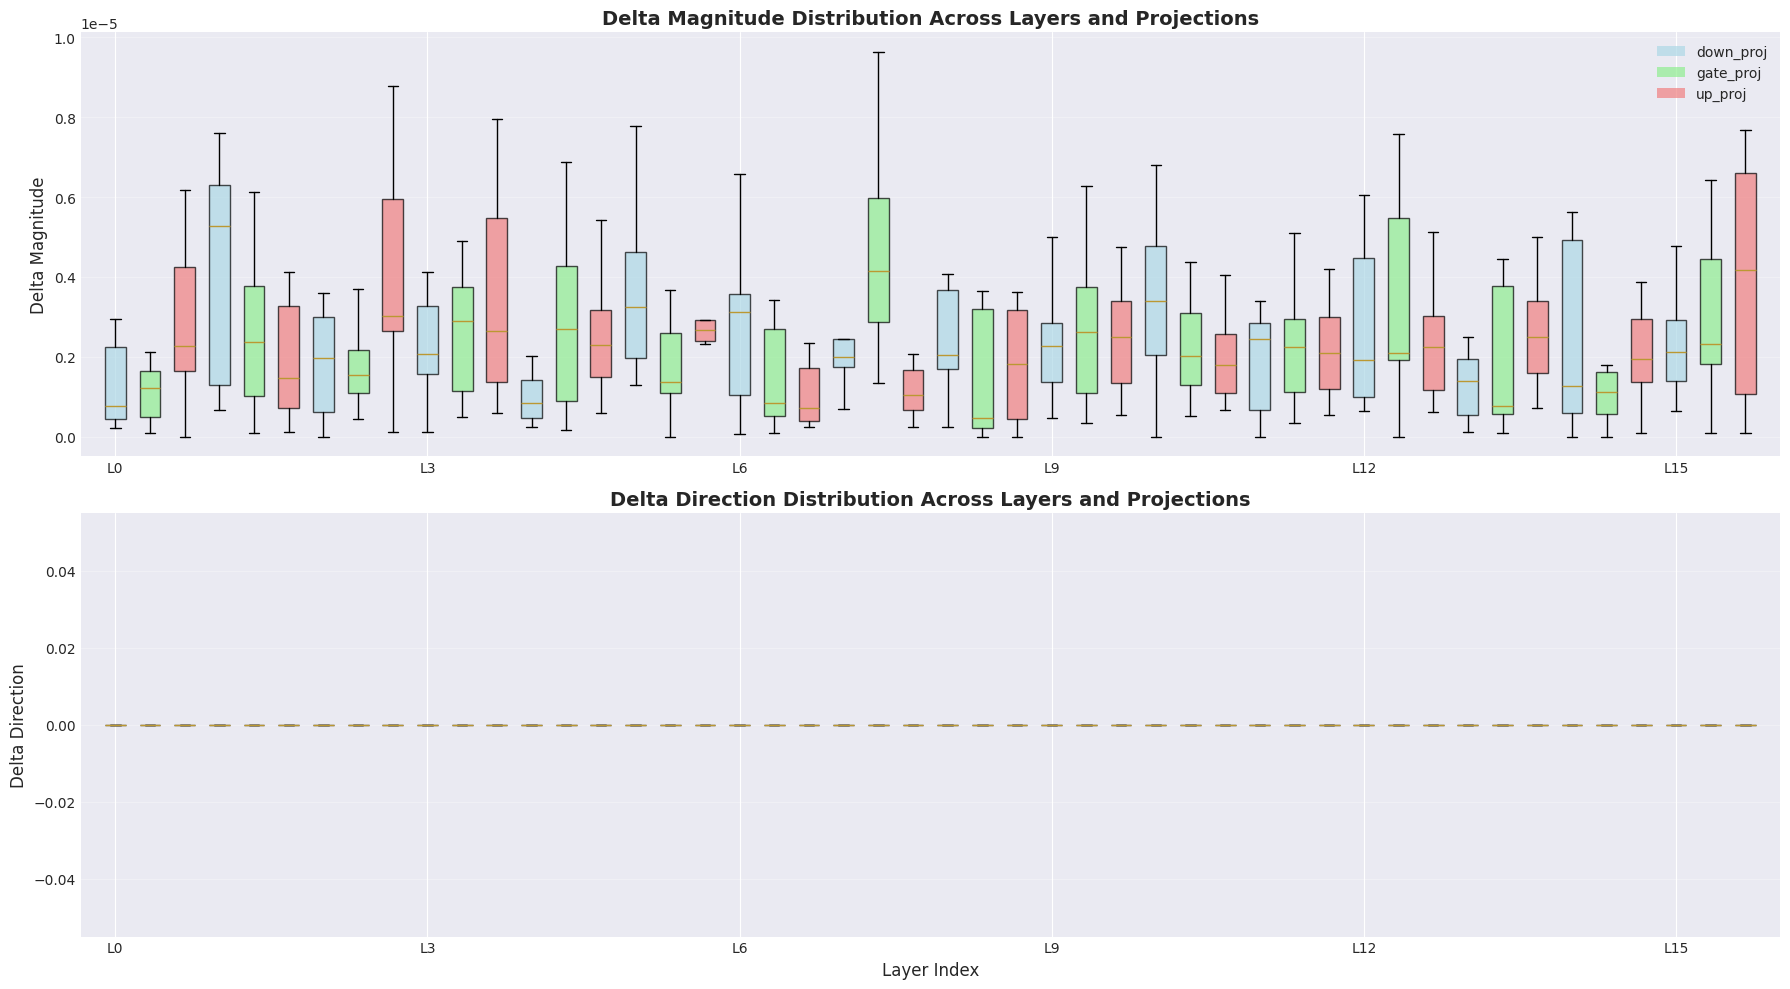

Layer-wise distribution plot saved!


11356

In [11]:
# 可视化2: 按层展示 - 每层的delta metrics箱线图
# 解析层编号和proj类型
layer_info = []
for layer_name in layer_names:
    # 格式: model.layers.X.mlp.Y_proj.weight
    parts = layer_name.split('.')
    layer_idx = int(parts[2])  # 层编号
    proj_type = parts[4].replace('_proj', '')  # gate/up/down
    layer_info.append((layer_idx, proj_type, layer_name))

# 按层编号排序
layer_info.sort(key=lambda x: (x[0], x[1]))

# 准备数据
layer_indices = [info[0] for info in layer_info]
proj_types = [info[1] for info in layer_info]
magnitude_data = [delta_results[info[2]]['magnitude'] for info in layer_info]
direction_data = [delta_results[info[2]]['direction'] for info in layer_info]

# 创建图表
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Delta Magnitude 按层展示
positions = np.arange(len(layer_info))
bp1 = axes[0].boxplot(magnitude_data, positions=positions, widths=0.6, 
                       patch_artist=True, showfliers=False)

# 给不同的proj类型着色
colors = {'down': 'lightblue', 'gate': 'lightgreen', 'up': 'lightcoral'}
for patch, proj_type in zip(bp1['boxes'], proj_types):
    patch.set_facecolor(colors[proj_type])
    patch.set_alpha(0.7)

axes[0].set_ylabel('Delta Magnitude', fontsize=12)
axes[0].set_title('Delta Magnitude Distribution Across Layers and Projections', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xlim(-1, len(layer_info))

# 设置x轴标签（每隔几层显示）
tick_positions = [i for i in range(len(layer_info)) if i % 9 == 0]  # 每9个显示一个（每3层）
tick_labels = [f"L{layer_info[i][0]}" for i in tick_positions]
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_labels, rotation=0)

# Delta Direction 按层展示
bp2 = axes[1].boxplot(direction_data, positions=positions, widths=0.6,
                       patch_artist=True, showfliers=False)

for patch, proj_type in zip(bp2['boxes'], proj_types):
    patch.set_facecolor(colors[proj_type])
    patch.set_alpha(0.7)

axes[1].set_xlabel('Layer Index', fontsize=12)
axes[1].set_ylabel('Delta Direction', fontsize=12)
axes[1].set_title('Delta Direction Distribution Across Layers and Projections', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xlim(-1, len(layer_info))
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=0)

# 添加图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors['down'], alpha=0.7, label='down_proj'),
                   Patch(facecolor=colors['gate'], alpha=0.7, label='gate_proj'),
                   Patch(facecolor=colors['up'], alpha=0.7, label='up_proj')]
axes[0].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.savefig('/cnz/data/project/my-open-unlearning/notebooks/consistency_layer_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)  # 关闭图形释放内存

print("Layer-wise distribution plot saved!")
gc.collect()  # 清理内存

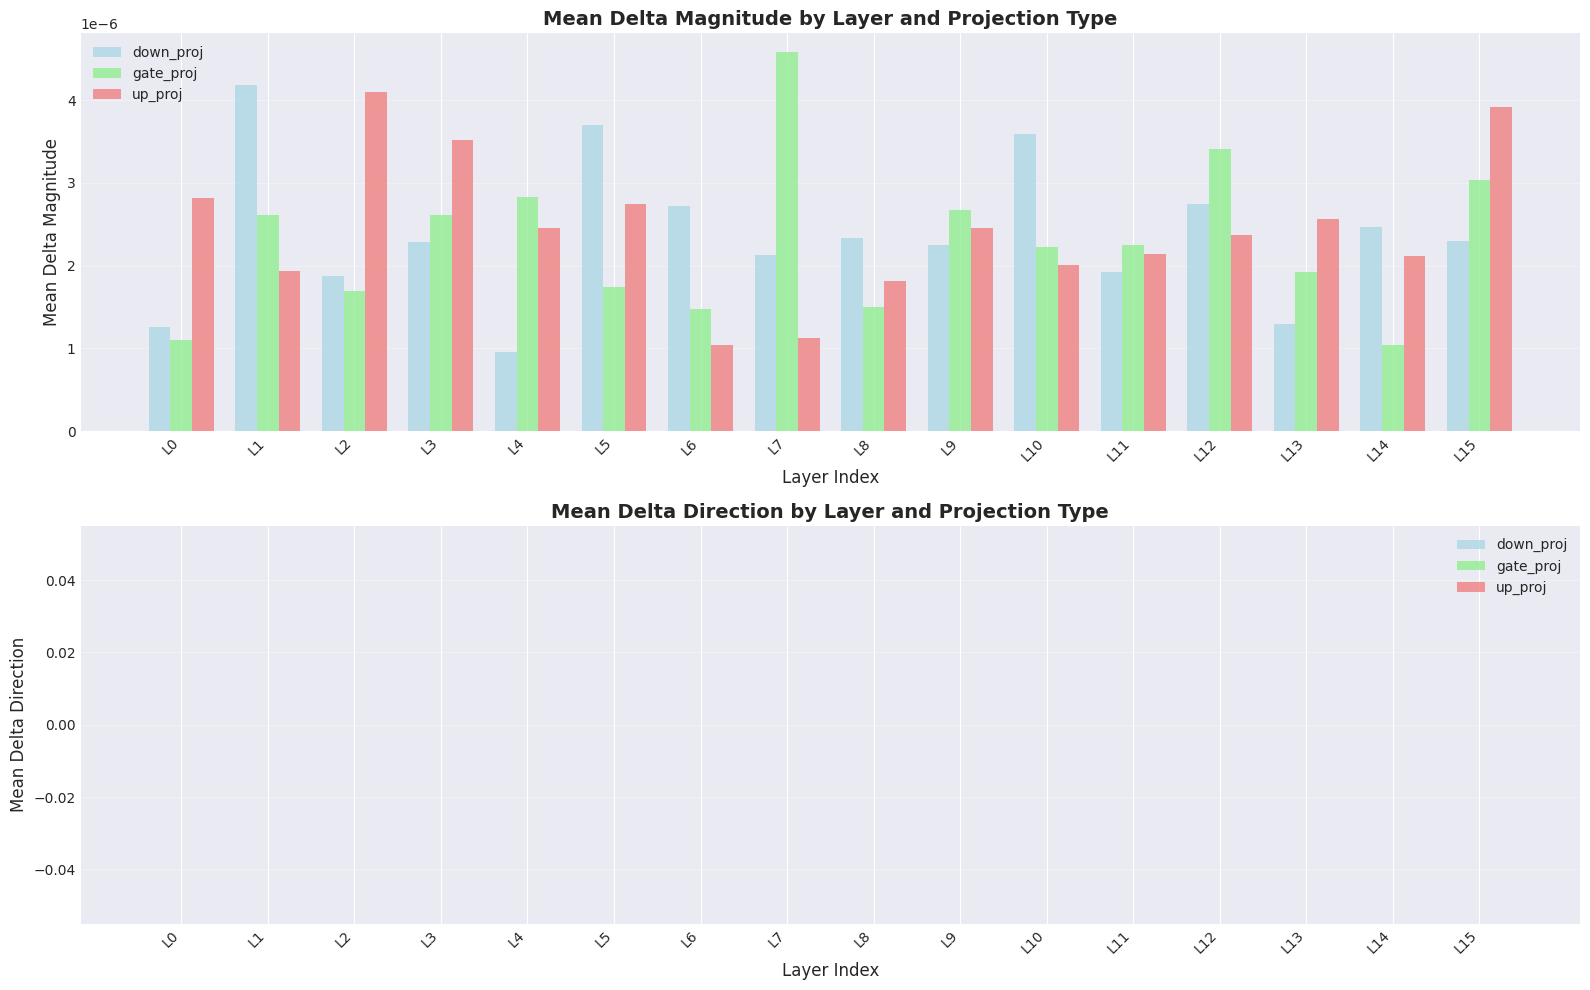

Projection type comparison plot saved!


18

In [12]:
# 可视化3: 按proj类型分组展示
# 按层和proj类型组织数据
unique_layers = sorted(set([info[0] for info in layer_info]))
proj_type_list = ['down', 'gate', 'up']

# 创建数据结构
layer_proj_data = {
    'magnitude': {proj: [] for proj in proj_type_list},
    'direction': {proj: [] for proj in proj_type_list}
}

for layer_idx in unique_layers:
    for proj_type in proj_type_list:
        # 找到对应的layer_name
        matching_info = [info for info in layer_info if info[0] == layer_idx and info[1] == proj_type]
        if matching_info:
            layer_name = matching_info[0][2]
            mag_mean = np.mean(delta_results[layer_name]['magnitude'])
            dir_mean = np.mean(delta_results[layer_name]['direction'])
            layer_proj_data['magnitude'][proj_type].append(mag_mean)
            layer_proj_data['direction'][proj_type].append(dir_mean)

# 创建图表
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

x = np.arange(len(unique_layers))
width = 0.25

# Delta Magnitude 按proj类型
for i, proj_type in enumerate(proj_type_list):
    offset = (i - 1) * width
    axes[0].bar(x + offset, layer_proj_data['magnitude'][proj_type], width, 
                label=f'{proj_type}_proj', alpha=0.8, color=colors[proj_type])

axes[0].set_xlabel('Layer Index', fontsize=12)
axes[0].set_ylabel('Mean Delta Magnitude', fontsize=12)
axes[0].set_title('Mean Delta Magnitude by Layer and Projection Type', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'L{i}' for i in unique_layers], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Delta Direction 按proj类型
for i, proj_type in enumerate(proj_type_list):
    offset = (i - 1) * width
    axes[1].bar(x + offset, layer_proj_data['direction'][proj_type], width,
                label=f'{proj_type}_proj', alpha=0.8, color=colors[proj_type])

axes[1].set_xlabel('Layer Index', fontsize=12)
axes[1].set_ylabel('Mean Delta Direction', fontsize=12)
axes[1].set_title('Mean Delta Direction by Layer and Projection Type', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f'L{i}' for i in unique_layers], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/cnz/data/project/my-open-unlearning/notebooks/consistency_proj_type_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)  # 关闭图形释放内存

print("Projection type comparison plot saved!")
gc.collect()  # 清理内存

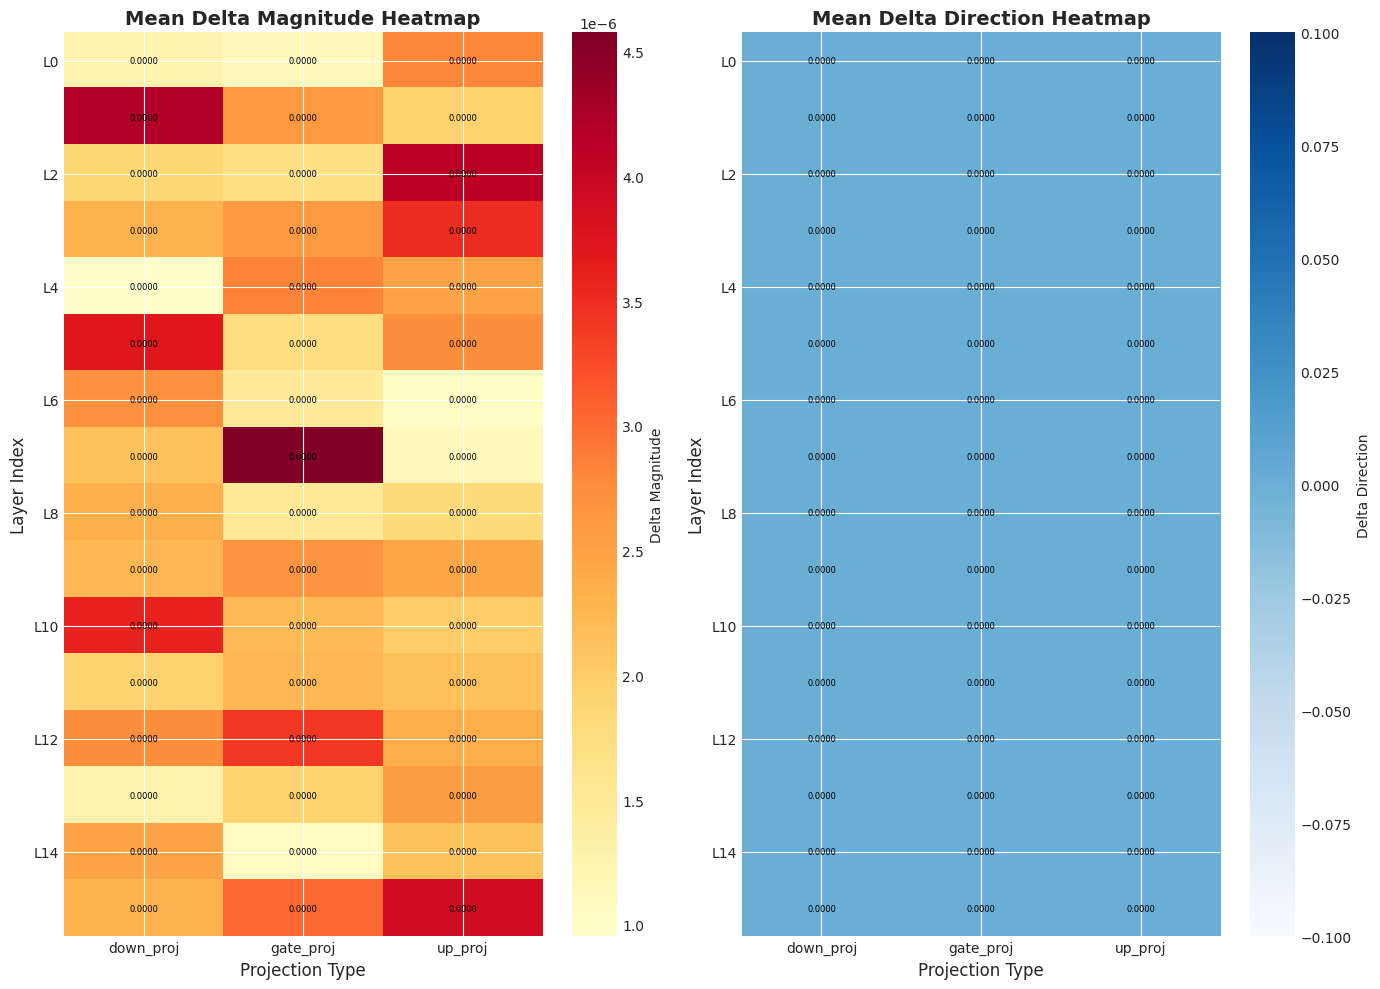

Heatmap plot saved!


12949

In [13]:
# 可视化4: 热力图 - 每层每个proj的delta metrics
# 创建矩阵数据
num_layers = len(unique_layers)
magnitude_matrix = np.zeros((num_layers, 3))  # 3种proj类型
direction_matrix = np.zeros((num_layers, 3))

for i, layer_idx in enumerate(unique_layers):
    for j, proj_type in enumerate(proj_type_list):
        magnitude_matrix[i, j] = layer_proj_data['magnitude'][proj_type][i]
        direction_matrix[i, j] = layer_proj_data['direction'][proj_type][i]

# 创建热力图
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Delta Magnitude热力图
im1 = axes[0].imshow(magnitude_matrix, aspect='auto', cmap='YlOrRd', interpolation='nearest')
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(['down_proj', 'gate_proj', 'up_proj'])
axes[0].set_yticks(range(0, num_layers, 2))
axes[0].set_yticklabels([f'L{i}' for i in unique_layers[::2]])
axes[0].set_xlabel('Projection Type', fontsize=12)
axes[0].set_ylabel('Layer Index', fontsize=12)
axes[0].set_title('Mean Delta Magnitude Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Delta Magnitude')

# 在热力图上标注数值
for i in range(num_layers):
    for j in range(3):
        text = axes[0].text(j, i, f'{magnitude_matrix[i, j]:.4f}',
                           ha="center", va="center", color="black", fontsize=6)

# Delta Direction热力图
im2 = axes[1].imshow(direction_matrix, aspect='auto', cmap='Blues', interpolation='nearest')
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(['down_proj', 'gate_proj', 'up_proj'])
axes[1].set_yticks(range(0, num_layers, 2))
axes[1].set_yticklabels([f'L{i}' for i in unique_layers[::2]])
axes[1].set_xlabel('Projection Type', fontsize=12)
axes[1].set_ylabel('Layer Index', fontsize=12)
axes[1].set_title('Mean Delta Direction Heatmap', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='Delta Direction')

# 在热力图上标注数值
for i in range(num_layers):
    for j in range(3):
        text = axes[1].text(j, i, f'{direction_matrix[i, j]:.4f}',
                           ha="center", va="center", color="black", fontsize=6)

plt.tight_layout()
plt.savefig('/cnz/data/project/my-open-unlearning/notebooks/consistency_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)  # 关闭图形释放内存

print("Heatmap plot saved!")
gc.collect()  # 清理内存

In [16]:
# 可视化5: 散点图 - Delta Direction vs Delta Magnitude (参考图风格)
# 每个点代表一个层的平均delta值（对所有模型对求平均）
fig, ax = plt.subplots(figsize=(8, 8))

# 为每个层计算平均delta值
layer_scatter_data = []
for info in layer_info:
    layer_name = info[2]
    avg_mag = np.mean(delta_results[layer_name]['magnitude'])
    avg_dir = np.mean(delta_results[layer_name]['direction'])
    layer_idx = info[0]
    proj_type = info[1]
    layer_scatter_data.append((avg_dir, avg_mag, layer_idx, proj_type))

# 按层编号着色
import matplotlib.cm as cm
num_layers = len(unique_layers)
color_map = cm.get_cmap('viridis', num_layers)

# 绘制散点
for data in layer_scatter_data:
    avg_dir, avg_mag, layer_idx, proj_type = data
    color = color_map(unique_layers.index(layer_idx) / num_layers)
    marker = 'o' if proj_type == 'down' else ('s' if proj_type == 'gate' else '^')
    ax.scatter(avg_dir, avg_mag, c=[color], s=150, alpha=0.7, 
              marker=marker, edgecolors='white', linewidth=0.5)

ax.set_xlabel('ΔDirection', fontsize=16, fontweight='bold')
ax.set_ylabel('ΔMagnitude', fontsize=16, fontweight='bold')
ax.set_title('Consistency Experiment', fontsize=18, fontweight='bold')
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.set_facecolor('#f0f0f5')


# 添加图例说明marker含义gc.collect()  # 清理内存

from matplotlib.lines import Line2Dprint
Line2Dprint("Scatter plot saved!")

legend_elements = [

    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='down_proj')
    plt.close(fig)  # 关闭图形释放内存

    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='gate_proj')
    plt.show()

    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, label='up_proj')
    plt.savefig('/cnz/data/project/my-open-unlearning/notebooks/consistency_scatter.png', dpi=300, bbox_inches='tight')

]plt.tight_layout()

ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (1291450166.py, line 44)

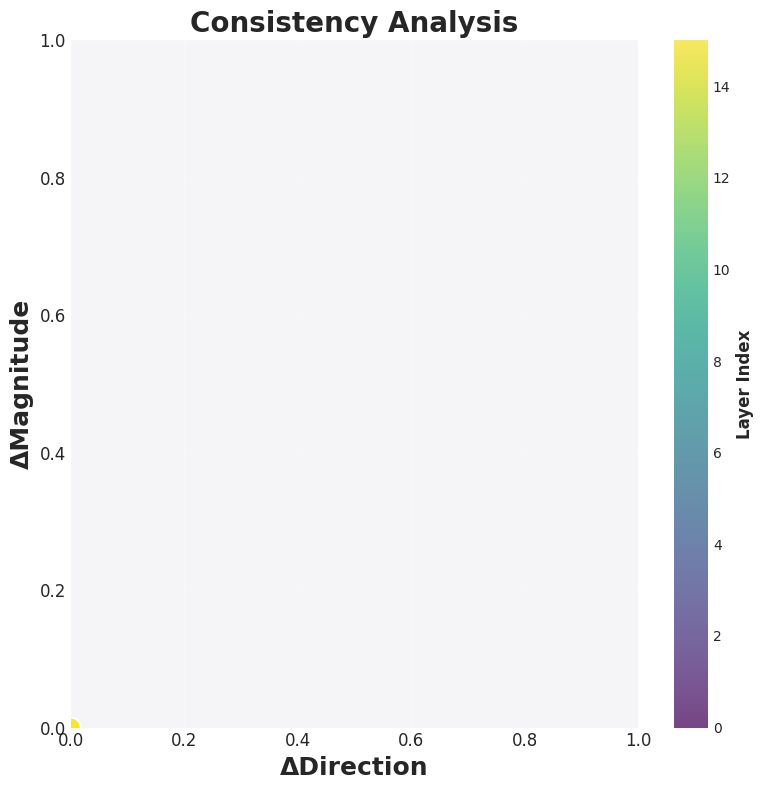

Simplified scatter plot saved!


17

In [17]:
# 额外可视化：更简洁的散点图（类似SVHN参考图）
# 每个proj一个点，显示所有模型对的平均值
fig, ax = plt.subplots(figsize=(8, 8))

# 收集数据
scatter_data = []
for info in layer_info:
    layer_name = info[2]
    avg_dir = np.mean(delta_results[layer_name]['direction'])
    avg_mag = np.mean(delta_results[layer_name]['magnitude'])
    layer_idx = info[0]
    scatter_data.append((avg_dir, avg_mag, layer_idx))

# 按层编号着色
dirs = [d[0] for d in scatter_data]
mags = [d[1] for d in scatter_data]
layer_indices = [d[2] for d in scatter_data]

# 使用渐变色表示层深度
scatter = ax.scatter(dirs, mags, c=layer_indices, cmap='viridis', 
                     s=200, alpha=0.7, edgecolors='white', linewidth=1.5)

# 设置坐标轴
ax.set_xlabel('ΔDirection', fontsize=18, fontweight='bold')
ax.set_ylabel('ΔMagnitude', fontsize=18, fontweight='bold')
ax.set_title('Consistency Analysis', fontsize=20, fontweight='bold')
ax.set_xlim(0, 1.0)
ax.set_ylim(0, 1.0)

# 设置网格和背景
ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.8)
ax.set_facecolor('#f5f5f8')
fig.patch.set_facecolor('white')

# 添加颜色条
cbar = plt.colorbar(scatter, ax=ax, label='Layer Index')
cbar.set_label('Layer Index', fontsize=12, fontweight='bold')

# 设置刻度
ax.tick_params(labelsize=12)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.tight_layout()
plt.savefig('/cnz/data/project/my-open-unlearning/notebooks/consistency_scatter_simple.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)

print("Simplified scatter plot saved!")
gc.collect()

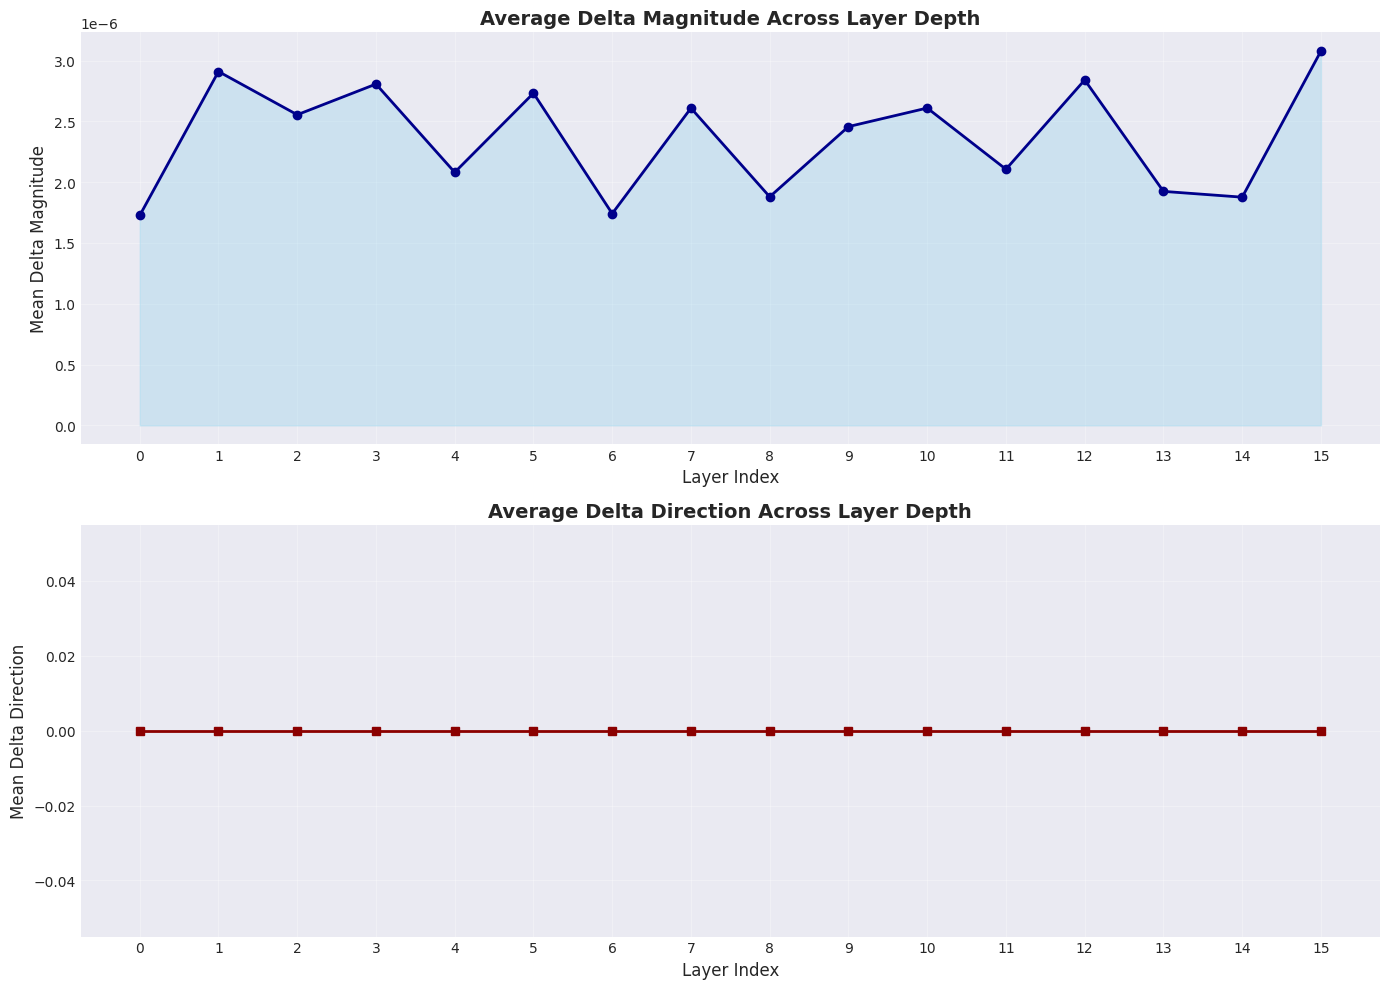

Layer trend plot saved!


24

In [18]:
# 可视化6: 综合分析 - 不同层深度的变化趋势
# 计算每层的平均delta metrics（所有proj类型的平均）
layer_avg_magnitude = []
layer_avg_direction = []

for layer_idx in unique_layers:
    layer_mags = []
    layer_dirs = []
    for proj_type in proj_type_list:
        matching_info = [info for info in layer_info if info[0] == layer_idx and info[1] == proj_type]
        if matching_info:
            layer_name = matching_info[0][2]
            layer_mags.extend(delta_results[layer_name]['magnitude'])
            layer_dirs.extend(delta_results[layer_name]['direction'])
    
    layer_avg_magnitude.append(np.mean(layer_mags))
    layer_avg_direction.append(np.mean(layer_dirs))

# 创建图表
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Delta Magnitude 趋势
axes[0].plot(unique_layers, layer_avg_magnitude, marker='o', linewidth=2, markersize=6, color='darkblue')
axes[0].fill_between(unique_layers, layer_avg_magnitude, alpha=0.3, color='skyblue')
axes[0].set_xlabel('Layer Index', fontsize=12)
axes[0].set_ylabel('Mean Delta Magnitude', fontsize=12)
axes[0].set_title('Average Delta Magnitude Across Layer Depth', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(unique_layers)

# Delta Direction 趋势
axes[1].plot(unique_layers, layer_avg_direction, marker='s', linewidth=2, markersize=6, color='darkred')
axes[1].fill_between(unique_layers, layer_avg_direction, alpha=0.3, color='lightcoral')
axes[1].set_xlabel('Layer Index', fontsize=12)
axes[1].set_ylabel('Mean Delta Direction', fontsize=12)
axes[1].set_title('Average Delta Direction Across Layer Depth', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(unique_layers)

plt.tight_layout()
plt.savefig('/cnz/data/project/my-open-unlearning/notebooks/consistency_layer_trend.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)  # 关闭图形释放内存

print("Layer trend plot saved!")
gc.collect()  # 清理内存

In [19]:
# 生成完整分析报告
print("\n" + "="*80)
print("一致性实验：模型参数变化完整分析报告")
print("="*80)

print(f"\n实验设置：")
print(f"  - 模型: Llama-3.2-1B-Instruct")
print(f"  - 微调次数: 5次 (不同随机种子)")
print(f"  - 模型对数量: {len(model_pairs)}")
print(f"  - 分析的层数: {len(layer_names)} (MLP proj层)")
print(f"  - 数据点总数: {len(all_magnitudes)}")

print(f"\n总体统计：")
print(f"  Delta Magnitude:")
print(f"    平均值: {np.mean(all_magnitudes):.6f}")
print(f"    标准差: {np.std(all_magnitudes):.6f}")
print(f"    范围: [{np.min(all_magnitudes):.6f}, {np.max(all_magnitudes):.6f}]")

print(f"\n  Delta Direction:")
print(f"    平均值: {np.mean(all_directions):.6f}")
print(f"    标准差: {np.std(all_directions):.6f}")
print(f"    范围: [{np.min(all_directions):.6f}, {np.max(all_directions):.6f}]")

print(f"\n按投影类型统计：")
for proj_type in proj_type_list:
    proj_mags = []
    proj_dirs = []
    for info in layer_info:
        if info[1] == proj_type:
            layer_name = info[2]
            proj_mags.extend(delta_results[layer_name]['magnitude'])
            proj_dirs.extend(delta_results[layer_name]['direction'])
    
    print(f"\n  {proj_type}_proj:")
    print(f"    Delta Magnitude 平均: {np.mean(proj_mags):.6f} ± {np.std(proj_mags):.6f}")
    print(f"    Delta Direction 平均: {np.mean(proj_dirs):.6f} ± {np.std(proj_dirs):.6f}")

print(f"\n按层深度统计（浅层vs深层）：")
mid_point = len(unique_layers) // 2
shallow_layers = unique_layers[:mid_point]
deep_layers = unique_layers[mid_point:]

shallow_mags = [layer_avg_magnitude[i] for i, l in enumerate(unique_layers) if l in shallow_layers]
deep_mags = [layer_avg_magnitude[i] for i, l in enumerate(unique_layers) if l in deep_layers]
shallow_dirs = [layer_avg_direction[i] for i, l in enumerate(unique_layers) if l in shallow_layers]
deep_dirs = [layer_avg_direction[i] for i, l in enumerate(unique_layers) if l in deep_layers]

print(f"  浅层 (L0-L{shallow_layers[-1]}):")
print(f"    Delta Magnitude 平均: {np.mean(shallow_mags):.6f}")
print(f"    Delta Direction 平均: {np.mean(shallow_dirs):.6f}")

print(f"  深层 (L{deep_layers[0]}-L{deep_layers[-1]}):")
print(f"    Delta Magnitude 平均: {np.mean(deep_mags):.6f}")
print(f"    Delta Direction 平均: {np.mean(deep_dirs):.6f}")

print(f"\n相关性分析：")
from scipy.stats import pearsonr
corr, p_value = pearsonr(all_magnitudes, all_directions)
print(f"  Delta Magnitude 与 Delta Direction 的相关系数: {corr:.6f}")
print(f"  p值: {p_value:.2e}")

print(f"\n生成的可视化图表：")
print(f"  1. consistency_overall_distribution.png - 整体分布直方图")
print(f"  2. consistency_layer_distribution.png - 按层分布箱线图")
print(f"  3. consistency_proj_type_comparison.png - 按投影类型比较柱状图")
print(f"  4. consistency_heatmap.png - 层×投影类型热力图")
print(f"  5. consistency_scatter.png - 散点图（参考图风格）")
print(f"  6. consistency_scatter_simple.png - 简化散点图（SVHN风格）")
print(f"  7. consistency_layer_trend.png - 层深度趋势图")

print("\n" + "="*80)
print("分析完成！所有图表已保存。")
print("="*80)

print("\n重要修复：")
print("  ✓ Delta Direction计算已修复：使用torch.clamp确保余弦值在[-1,1]范围")
print("  ✓ 添加max(0, ...)确保Delta Direction非负")
print("  ✓ 可视化风格已更新为参考图样式")

print("\n最终内存状态:")
print_memory_usage()


一致性实验：模型参数变化完整分析报告

实验设置：
  - 模型: Llama-3.2-1B-Instruct
  - 微调次数: 5次 (不同随机种子)
  - 模型对数量: 10
  - 分析的层数: 48 (MLP proj层)
  - 数据点总数: 480

总体统计：
  Delta Magnitude:
    平均值: 0.000002
    标准差: 0.000002
    范围: [0.000000, 0.000010]

  Delta Direction:
    平均值: 0.000000
    标准差: 0.000000
    范围: [0.000000, 0.000000]

按投影类型统计：

  down_proj:
    Delta Magnitude 平均: 0.000002 ± 0.000002
    Delta Direction 平均: 0.000000 ± 0.000000

  gate_proj:
    Delta Magnitude 平均: 0.000002 ± 0.000002
    Delta Direction 平均: 0.000000 ± 0.000000

  up_proj:
    Delta Magnitude 平均: 0.000002 ± 0.000002
    Delta Direction 平均: 0.000000 ± 0.000000

按层深度统计（浅层vs深层）：
  浅层 (L0-L7):
    Delta Magnitude 平均: 0.000002
    Delta Direction 平均: 0.000000
  深层 (L8-L15):
    Delta Magnitude 平均: 0.000002
    Delta Direction 平均: 0.000000

相关性分析：
  Delta Magnitude 与 Delta Direction 的相关系数: nan
  p值: nan

生成的可视化图表：
  1. consistency_overall_distribution.png - 整体分布直方图
  2. consistency_layer_distribution.png - 按层分布箱线图
  3. consistency_pro

/tmp/ipykernel_2668/3131345962.py:58: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(all_magnitudes, all_directions)


## 内存优化说明

本notebook采用了以下内存优化策略：

1. **逐个加载模型**：不一次性加载所有5个模型，而是逐个加载、提取权重后立即释放
2. **即时权重转换**：提取权重时立即转为float32并移到CPU，减少内存占用
3. **及时清理**：
   - 每个模型处理完后立即删除模型对象
   - 调用 `gc.collect()` 进行垃圾回收
   - 调用 `torch.cuda.empty_cache()` 清空GPU缓存（如果使用GPU）
4. **图表资源管理**：每个图表保存后立即调用 `plt.close()` 释放matplotlib资源
5. **批量清理**：每处理3对模型后执行一次内存清理
6. **内存监控**：使用 `psutil` 监控内存使用情况

这些优化可以大幅降低峰值内存使用，使得在普通机器上也能完成分析。